# Smart Spend

Smart spend adalah website berbasis AI yang digunakan untuk mengatur budgeting para pengguna. Ide project ini dibuat karena kurangnya orang dalam mengatur keuangan sehingga keadaan keuangan menjadi boncos. dengan adanya website berbasis AI ini diharapkan orang orang bisa mengatur budget sesuai dengan keadaan keuangan sekaligus rekomendasi dari Smart Spend

<hr>

Pembuatan Model Clustering untuk Sistem Rekomendasi

# Gathering Data

Import semua library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy import stats
import warnings
warnings.filterwarnings('ignore')


Import Dataset

In [2]:
url = "https://drive.google.com/uc?export=download&id=1n7t9XudgUGaJkETkJaSJAPSvvRE7VMOF"
df = pd.read_csv(url)
df.head()

,id,provinsi,klasifikasi_wilayah,jenis_kelamin,usia,pendidikan_terakhir,status_pekerjaan,status_pernikahan,jumlah_tanggungan,pendapatan_bulanan,...,pengeluaran_kesehatan,pengeluaran_pendidikan,pengeluaran_transportasi,pengeluaran_komunikasi,pengeluaran_hiburan_rekreasi,cicilan_hutang,tabungan_bulanan,rasio_tabungan_persen,skor_literasi_keuangan,label_rekomendasi
0,1160,DKI Jakarta,Perkotaan,Perempuan,25.0,SMP,Buruh/Pekerja Harian,Menikah,1.0,3350000.0,...,129000.0,116000.0,162000.0,100000.0,98000.0,0.0,827000.0,24.7,45.6,Keuangan Sehat
1,1824,DKI Jakarta,Perkotaan,Perempuan,23.0,SD,PNS/ASN,Menikah,2.0,9500000.0,...,695000.0,681000.0,1129000.0,341000.0,272000.0,1686000.0,1347000.0,14.2,49.1,Cukup Baik
2,979,Sumatera Selatan,Perkotaan,Laki-laki,59.0,Diploma,PNS/ASN,Menikah,NaN,6500000.0,...,236000.0,271000.0,441000.0,170000.0,186000.0,0.0,1876000.0,28.9,NaN,Keuangan Sehat
3,760,Bali,Perkotaan,Perempuan,47.0,SD,Buruh/Pekerja Harian,Menikah,2.0,1700000.0,...,58000.0,38000.0,86000.0,30000.0,30000.0,0.0,426000.0,25.1,32.5,Keuangan Sehat
4,875,Sumatera Selatan,Perkotaan,Laki-laki,17.0,Pascasarjana (S2/S3),Buruh/Pekerja Harian,NaN,3.0,NaN,...,93000.0,197000.0,291000.0,140000.0,141000.0,NaN,448000.0,NaN,77.3,Cukup Baik


In [3]:
df.describe(include='all')

,id,provinsi,klasifikasi_wilayah,jenis_kelamin,usia,pendidikan_terakhir,status_pekerjaan,status_pernikahan,jumlah_tanggungan,pendapatan_bulanan,...,pengeluaran_kesehatan,pengeluaran_pendidikan,pengeluaran_transportasi,pengeluaran_komunikasi,pengeluaran_hiburan_rekreasi,cicilan_hutang,tabungan_bulanan,rasio_tabungan_persen,skor_literasi_keuangan,label_rekomendasi
count,2150.000000,2150,2150,2150,2107.000000,2086,2064,2086,2043.000000,1.978000e+03,...,2.021000e+03,1.957000e+03,2.043000e+03,2.064000e+03,1978.000000,1.935000e+03,2.000000e+03,2000.000000,2043.000000,2150
unique,NaN,12,2,2,NaN,7,6,3,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,Jawa Barat,Perkotaan,Laki-laki,NaN,SMA/SMK,Karyawan Swasta,Menikah,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Keuangan Sehat
freq,NaN,418,1240,1093,NaN,764,711,1291,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1206
mean,1002.041395,NaN,NaN,NaN,35.564309,NaN,NaN,NaN,1.325991,4.195930e+06,...,1.676353e+05,1.206418e+05,2.982726e+05,1.484375e+05,125804.853387,1.942362e+05,9.058405e+05,21.490450,53.808468,NaN
std,577.341356,NaN,NaN,NaN,11.681310,NaN,NaN,NaN,1.301489,3.356503e+06,...,1.674059e+05,1.894444e+05,2.926701e+05,1.482358e+05,128346.629073,3.512631e+05,8.442213e+05,7.903261,14.825498,NaN
min,1.000000,NaN,NaN,NaN,17.000000,NaN,NaN,NaN,0.000000,5.000000e+05,...,7.000000e+03,0.000000e+00,1.300000e+04,6.000000e+03,4000.000000,0.000000e+00,4.500000e+04,8.000000,6.300000,NaN
25%,501.250000,NaN,NaN,NaN,27.000000,NaN,NaN,NaN,0.000000,1.800000e+06,...,5.200000e+04,0.000000e+00,9.800000e+04,4.700000e+04,37000.000000,0.000000e+00,3.420000e+05,14.400000,43.300000,NaN
50%,1000.500000,NaN,NaN,NaN,35.000000,NaN,NaN,NaN,1.000000,3.300000e+06,...,1.140000e+05,4.000000e+04,2.080000e+05,1.005000e+05,84000.000000,5.000000e+03,6.595000e+05,21.300000,53.900000,NaN
75%,1503.750000,NaN,NaN,NaN,44.000000,NaN,NaN,NaN,2.000000,5.700000e+06,...,2.210000e+05,1.630000e+05,3.970000e+05,1.940000e+05,168000.000000,2.475000e+05,1.192250e+06,28.400000,64.300000,NaN


# Kesimpulan
Dari dataset tersebut terdapat banyak data pendapatan dan pengeluaran setiap orangnya sekaligus pendidikan,pekerjaan,usia,jenis kelamin dan status pernikahan sehingga dengan adanya data tersebut dari user kita bisa memberikan rekomendasi yang tepat

# Assesing Data

In [4]:
df.isnull().sum()

,0
id,0
provinsi,0
klasifikasi_wilayah,0
jenis_kelamin,0
usia,43
pendidikan_terakhir,64
status_pekerjaan,86
status_pernikahan,64
jumlah_tanggungan,107
pendapatan_bulanan,172


In [5]:
df.duplicated().sum()

np.int64(12)

In [6]:
print(len(df))

2150


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2150 entries, 0 to 2149
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id                             2150 non-null   int64  
 1   provinsi                       2150 non-null   object 
 2   klasifikasi_wilayah            2150 non-null   object 
 3   jenis_kelamin                  2150 non-null   object 
 4   usia                           2107 non-null   float64
 5   pendidikan_terakhir            2086 non-null   object 
 6   status_pekerjaan               2064 non-null   object 
 7   status_pernikahan              2086 non-null   object 
 8   jumlah_tanggungan              2043 non-null   float64
 9   pendapatan_bulanan             1978 non-null   float64
 10  total_pengeluaran              2150 non-null   int64  
 11  pengeluaran_makanan_pokok      2021 non-null   float64
 12  pengeluaran_lauk_pauk          2021 non-null   f

jumlah dataset sekitar 2150 baris. terdapat banyak missing values sekaligus duplikasi data sehingga kita harus menggantinya dengan median dan modus karena jumlah dataset yang kecil  

# Cleaning Data

Mengatasi missing value dengan median dan modus dan drop duplicated data

In [8]:
df.drop_duplicates(inplace=True)

missing_values = df.isnull().sum()
less = missing_values[missing_values < 2000].index

numeric_features = df[less].select_dtypes(include=['number']).columns
df[numeric_features] = df[numeric_features].fillna(df[numeric_features].median())

kategorical_features = df[less].select_dtypes(include=['object']).columns

for column in kategorical_features:
    df[column] = df[column].fillna(df[column].mode()[0])

df.isnull().sum()

,0
id,0
provinsi,0
klasifikasi_wilayah,0
jenis_kelamin,0
usia,0
pendidikan_terakhir,0
status_pekerjaan,0
status_pernikahan,0
jumlah_tanggungan,0
pendapatan_bulanan,0


In [9]:
df.drop('id', axis=1, inplace=True)
df.drop('label_rekomendasi', axis=1, inplace=True)
print("Kolom yang tersisa:", df.shape[1], "kolom")
df.head()


Kolom yang tersisa: 26 kolom


,provinsi,klasifikasi_wilayah,jenis_kelamin,usia,pendidikan_terakhir,status_pekerjaan,status_pernikahan,jumlah_tanggungan,pendapatan_bulanan,total_pengeluaran,...,pengeluaran_pakaian,pengeluaran_kesehatan,pengeluaran_pendidikan,pengeluaran_transportasi,pengeluaran_komunikasi,pengeluaran_hiburan_rekreasi,cicilan_hutang,tabungan_bulanan,rasio_tabungan_persen,skor_literasi_keuangan
0,DKI Jakarta,Perkotaan,Perempuan,25.0,SMP,Buruh/Pekerja Harian,Menikah,1.0,3350000.0,2523000,...,110000.0,129000.0,116000.0,162000.0,100000.0,98000.0,0.0,827000.0,24.7,45.6
1,DKI Jakarta,Perkotaan,Perempuan,23.0,SD,PNS/ASN,Menikah,2.0,9500000.0,8153000,...,500000.0,695000.0,681000.0,1129000.0,341000.0,272000.0,1686000.0,1347000.0,14.2,49.1
2,Sumatera Selatan,Perkotaan,Laki-laki,59.0,Diploma,PNS/ASN,Menikah,1.0,6500000.0,4624000,...,106000.0,236000.0,271000.0,441000.0,170000.0,186000.0,0.0,1876000.0,28.9,53.9
3,Bali,Perkotaan,Perempuan,47.0,SD,Buruh/Pekerja Harian,Menikah,2.0,1700000.0,1274000,...,40000.0,58000.0,38000.0,86000.0,30000.0,30000.0,0.0,426000.0,25.1,32.5
4,Sumatera Selatan,Perkotaan,Laki-laki,17.0,Pascasarjana (S2/S3),Buruh/Pekerja Harian,Menikah,3.0,3300000.0,2802000,...,148000.0,93000.0,197000.0,291000.0,140000.0,141000.0,3000.0,448000.0,21.3,77.3


# Data Dictionary



| Nama Kolom | Tipe Data | Kategori | Deskripsi | Contoh Nilai |
|---|---|---|---|---|
| `id` | int | Identitas | ID unik responden, di-drop sebelum modeling | 1, 2, 3, … |
| `usia` | int | Demografi | Usia responden (tahun) | 22, 35, 48 |
| `jenis_kelamin` | object → int | Demografi | Jenis kelamin, di-encode LabelEncoder | Laki-laki / Perempuan → 0/1 |
| `status_pernikahan` | object → int | Demografi | Status pernikahan, di-encode LabelEncoder | Menikah, Belum Menikah, Cerai → 0/1/2 |
| `pendidikan` | object | Demografi | Tingkat pendidikan terakhir | SD, SMP, SMA, S1, S2 |
| `status_pekerjaan` | object | Demografi | Jenis pekerjaan saat ini | PNS/ASN, Buruh/Pekerja Harian, dll. |
| `jumlah_tanggungan` | int | Demografi | Jumlah orang yang ditanggung finansial | 0, 1, 2, 3, … |
| `pendapatan_bulanan` | float | Keuangan | Total pendapatan bersih per bulan (Rp) | 3.000.000, 7.500.000 |
| `pengeluaran_bulanan` | float | Keuangan | Total pengeluaran per bulan (Rp) | 2.500.000, 6.000.000 |
| `tabungan_bulanan` | float | Keuangan | Jumlah tabungan per bulan (Rp) | 500.000, 1.500.000 |
| `label_rekomendasi` | object | Target | Label kondisi keuangan, di-drop sebelum clustering | Sehat (1), Cukup Baik (0), Perlu Perbaikan (2) |

# Menentukan Pertanyaan Bisnis

- Pertanyaan 1 : Apakah orang yang bekerja sebagai PNS/ASN memiliki rata-rata tabungan bulanan lebih tinggi dibandingkan Buruh/Pekerja Harian berdasarkan data yang tersedia?
- Pertanyaan 2 : Bagaimana pola distribusi rasio tabungan (rasio_tabungan_persen) berdasarkan status pekerjaan, dan kelompok pekerjaan mana yang paling rendah rasio tabungannya?

# Exploratory Data Analysis

In [10]:
df.describe(include='all')

,provinsi,klasifikasi_wilayah,jenis_kelamin,usia,pendidikan_terakhir,status_pekerjaan,status_pernikahan,jumlah_tanggungan,pendapatan_bulanan,total_pengeluaran,...,pengeluaran_pakaian,pengeluaran_kesehatan,pengeluaran_pendidikan,pengeluaran_transportasi,pengeluaran_komunikasi,pengeluaran_hiburan_rekreasi,cicilan_hutang,tabungan_bulanan,rasio_tabungan_persen,skor_literasi_keuangan
count,2138,2138,2138,2138.000000,2138,2138,2138,2138.000000,2.138000e+03,2.138000e+03,...,2.138000e+03,2.138000e+03,2.138000e+03,2.138000e+03,2.138000e+03,2138.000000,2.138000e+03,2.138000e+03,2138.000000,2138.000000
unique,12,2,2,NaN,7,6,3,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Jawa Barat,Perkotaan,Laki-laki,NaN,SMA/SMK,Karyawan Swasta,Menikah,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,417,1232,1087,NaN,823,791,1349,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,35.538354,NaN,NaN,NaN,1.311974,4.124649e+06,3.279066e+06,...,1.478746e+05,1.644032e+05,1.137558e+05,2.940103e+05,1.466076e+05,122467.726848,1.751249e+05,8.877376e+05,21.459448,53.841581
std,NaN,NaN,NaN,11.561626,NaN,NaN,NaN,1.271500,3.231355e+06,2.674103e+06,...,1.429009e+05,1.628294e+05,1.825905e+05,2.863638e+05,1.457926e+05,123605.820322,3.386570e+05,8.165530e+05,7.622701,14.461226
min,NaN,NaN,NaN,17.000000,NaN,NaN,NaN,0.000000,5.000000e+05,3.310000e+05,...,6.000000e+03,7.000000e+03,0.000000e+00,1.300000e+04,6.000000e+03,4000.000000,0.000000e+00,4.500000e+04,8.000000,6.300000
25%,NaN,NaN,NaN,27.000000,NaN,NaN,NaN,0.000000,1.950000e+06,1.413250e+06,...,5.200000e+04,5.600000e+04,0.000000e+00,1.030000e+05,4.900000e+04,39000.000000,0.000000e+00,3.610000e+05,15.000000,44.100000
50%,NaN,NaN,NaN,35.000000,NaN,NaN,NaN,1.000000,3.300000e+06,2.576500e+06,...,1.060000e+05,1.140000e+05,4.000000e+04,2.080000e+05,1.005000e+05,84000.000000,3.000000e+03,6.590000e+05,21.300000,53.900000
75%,NaN,NaN,NaN,43.000000,NaN,NaN,NaN,2.000000,5.350000e+06,4.397500e+06,...,1.920000e+05,2.120000e+05,1.470000e+05,3.890000e+05,1.890000e+05,158000.000000,2.080000e+05,1.122000e+06,27.800000,63.900000


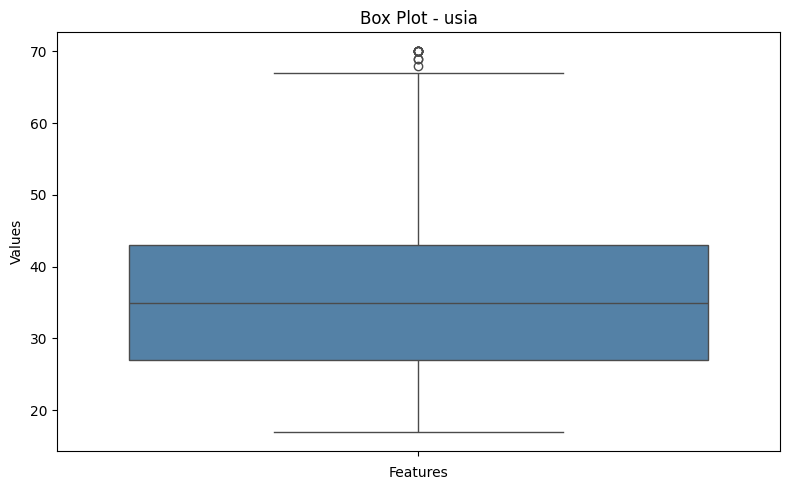

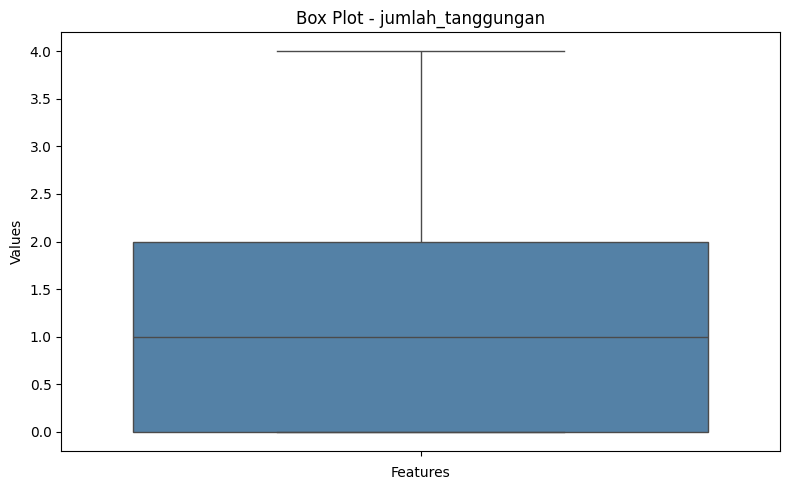

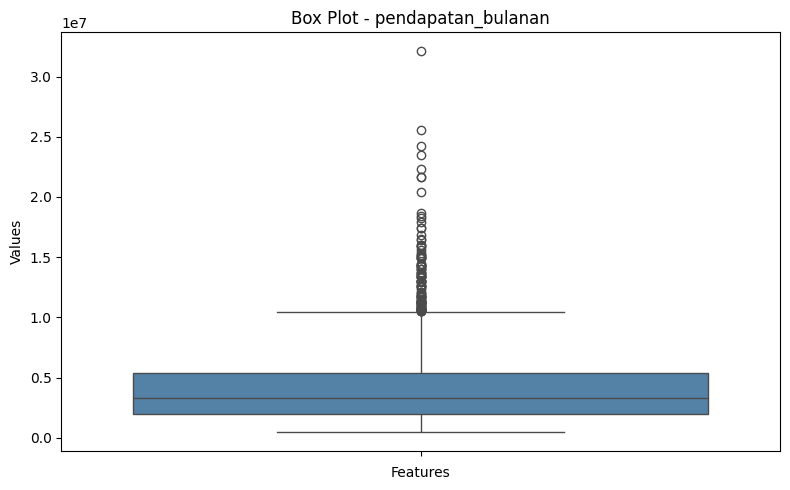

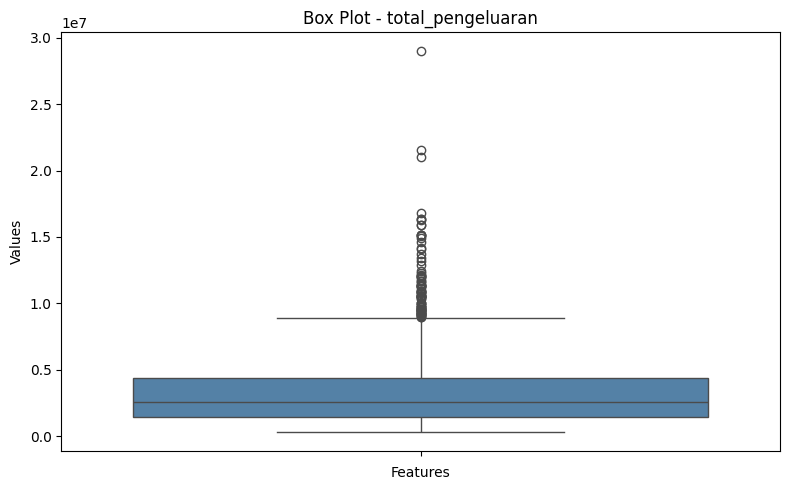

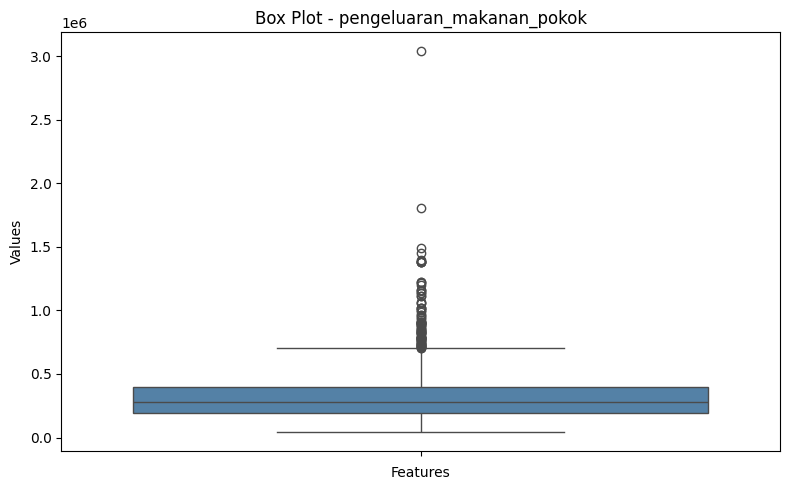

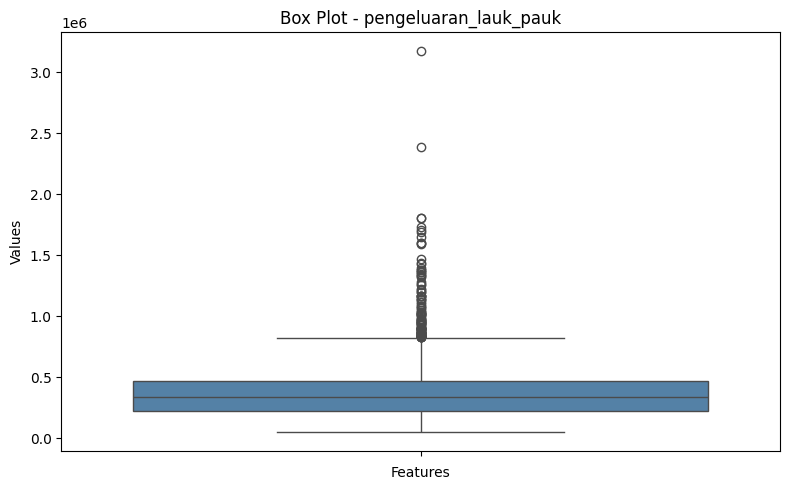

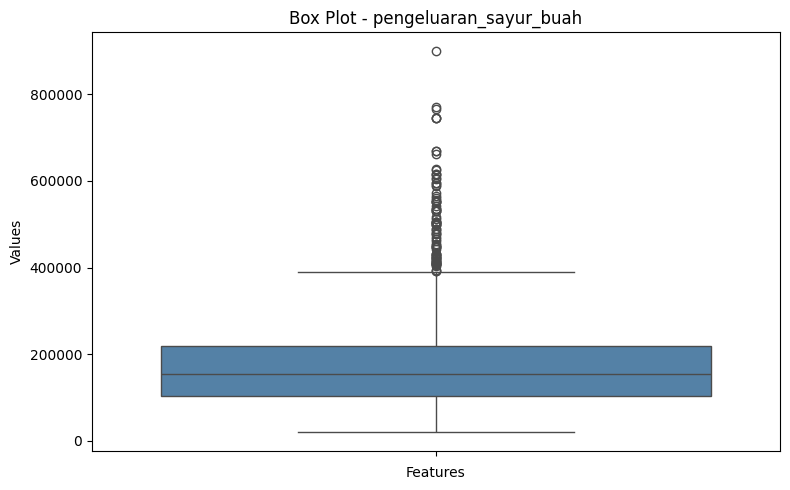

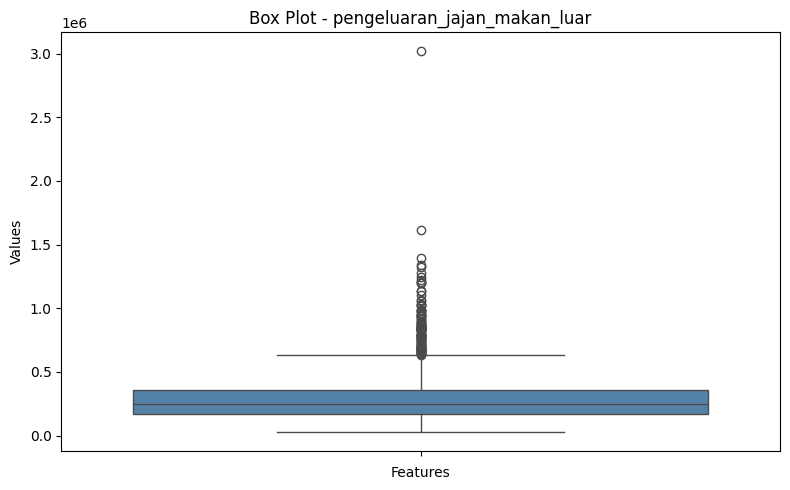

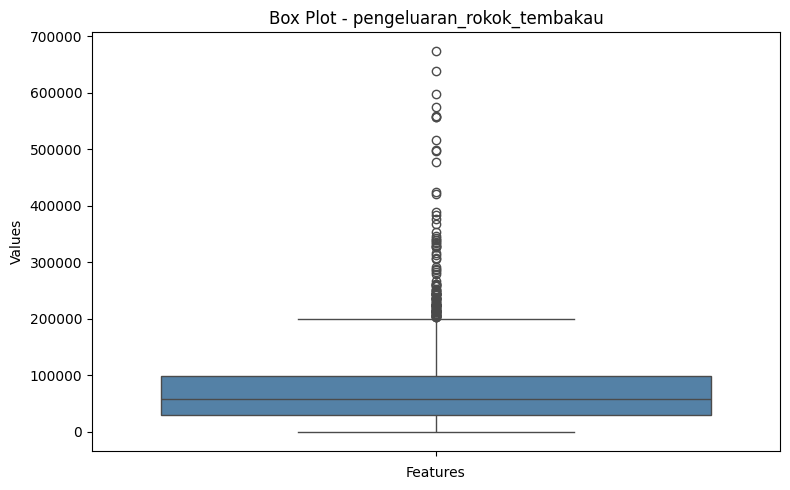

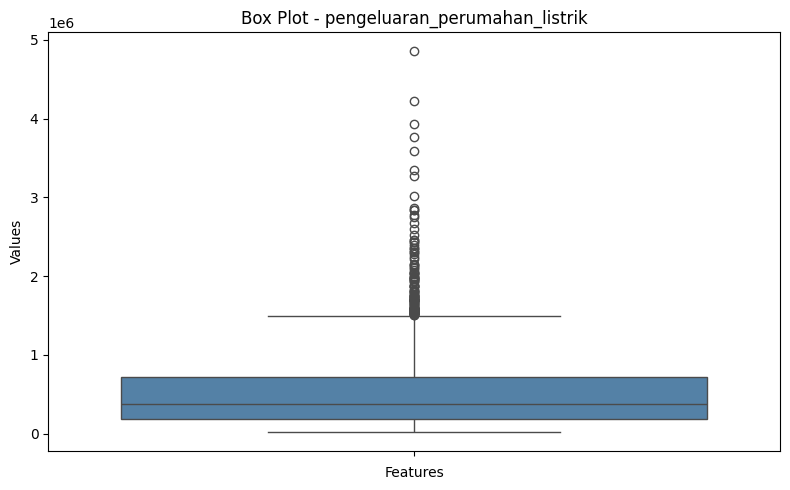

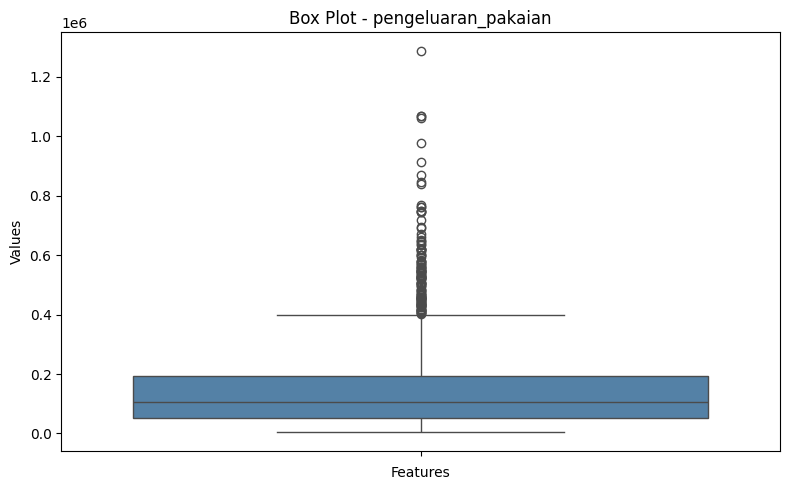

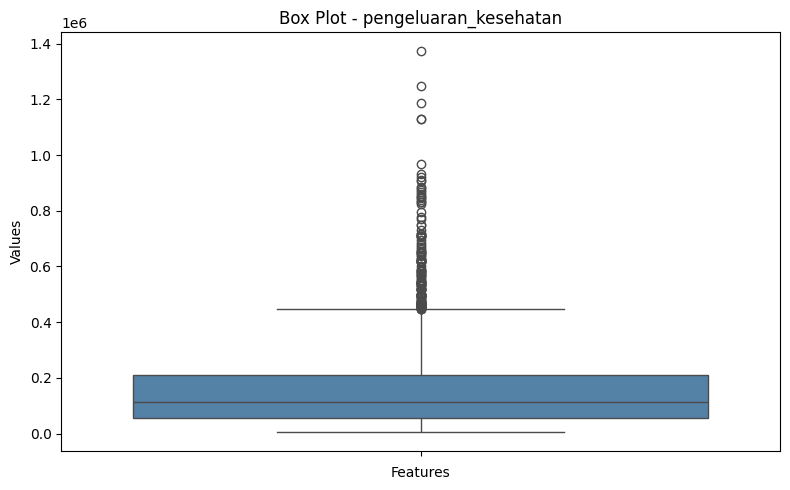

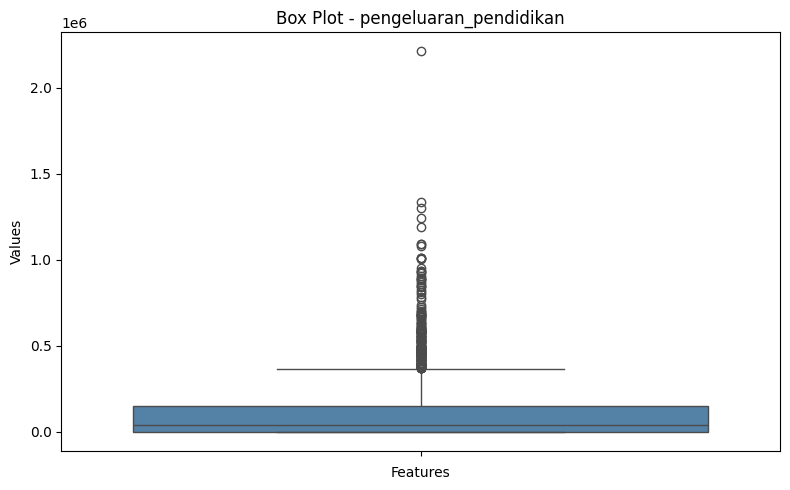

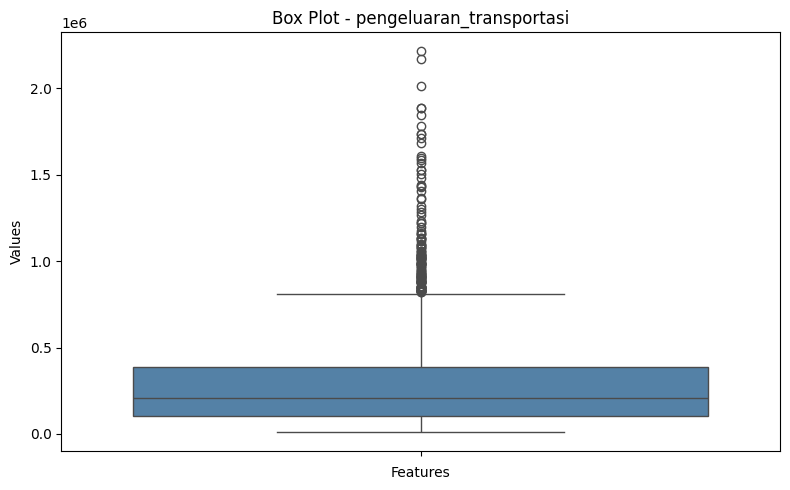

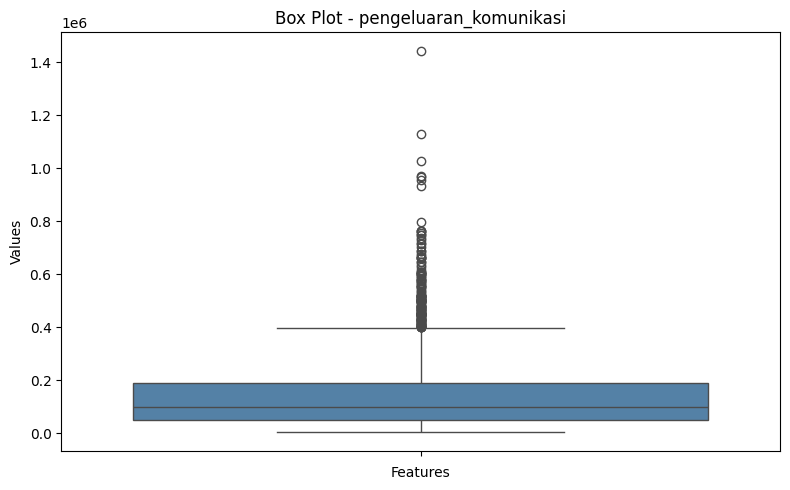

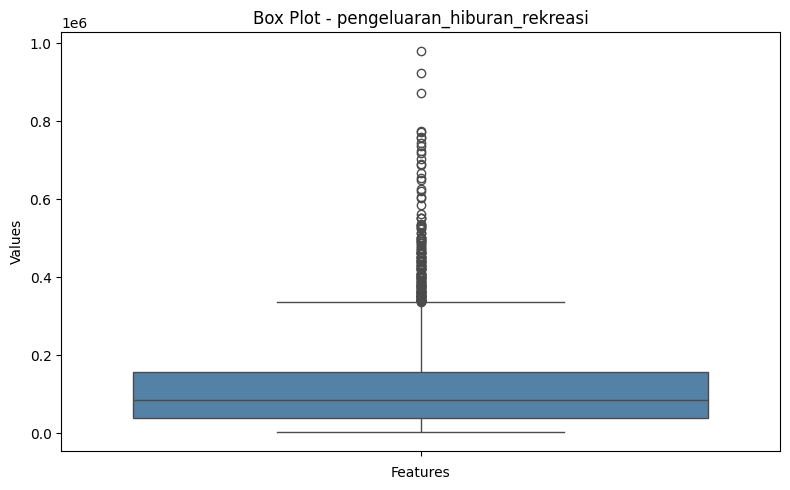

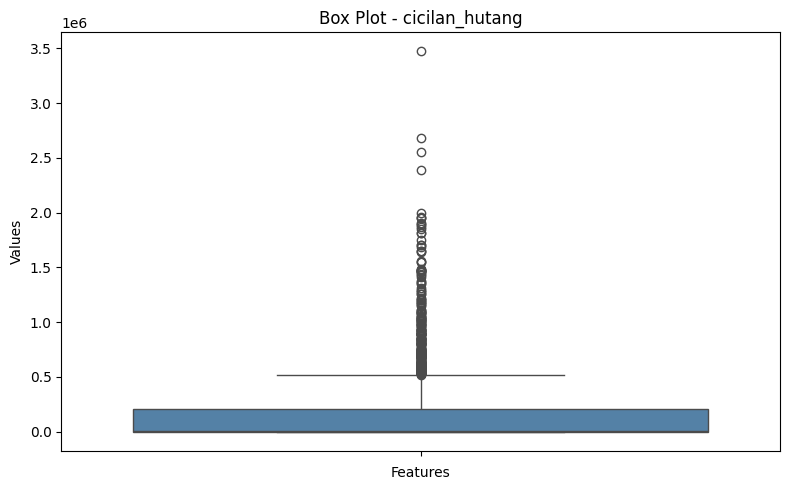

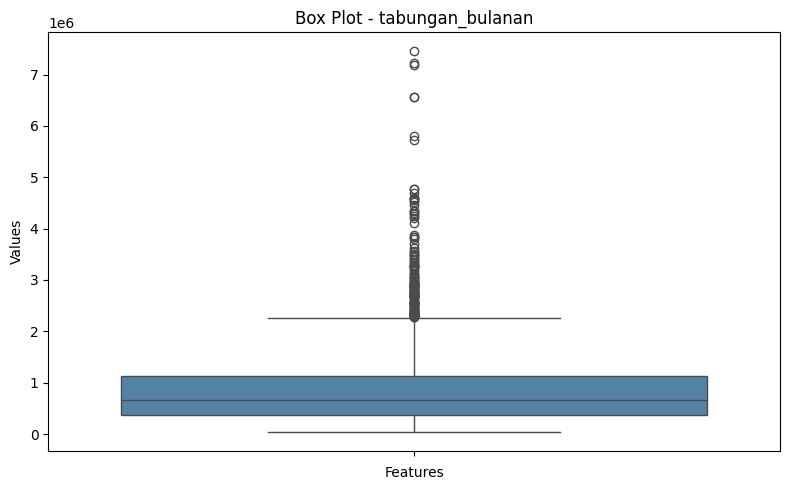

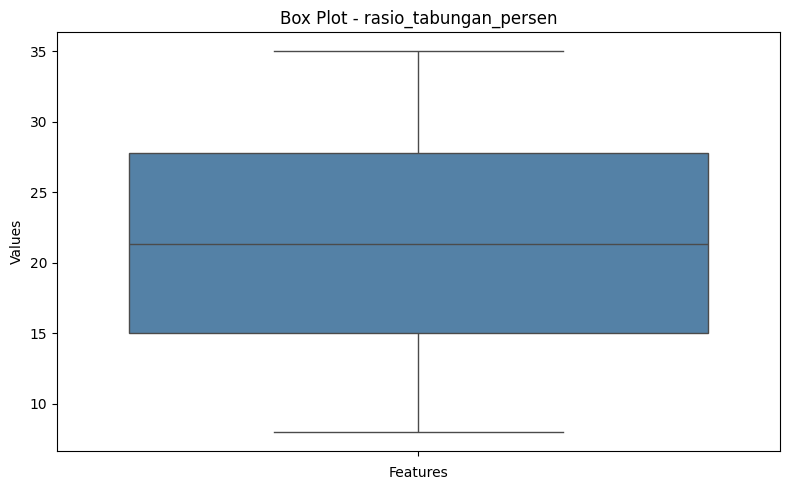

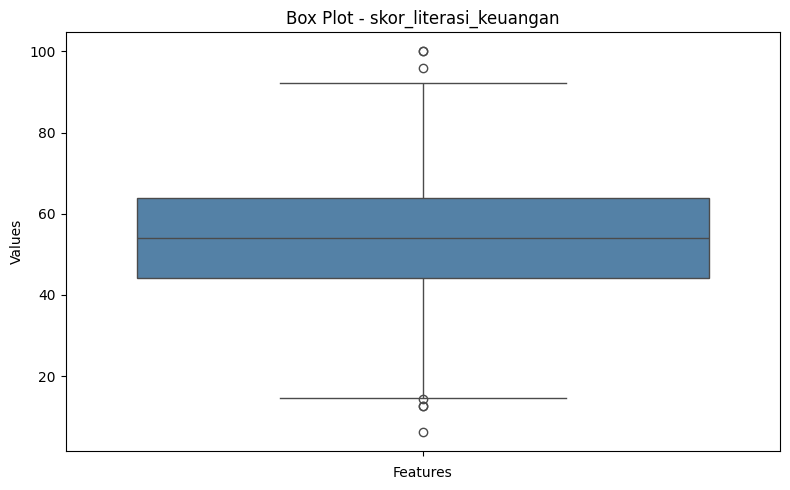

In [11]:
df_numeric = df.select_dtypes(include='number')

for column in df_numeric:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df_numeric, y=column, color='steelblue')
    plt.xlabel('Features')
    plt.ylabel('Values')
    plt.title(f'Box Plot - {column}')
    plt.tight_layout()
    plt.show()

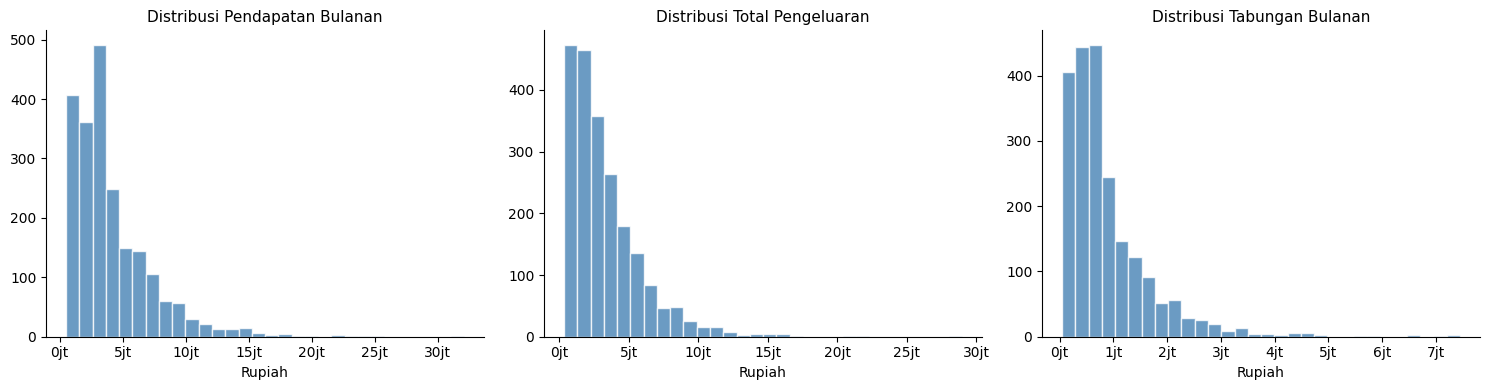

In [12]:
# Distribusi fitur keuangan utama
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, label in zip(axes,
    ['pendapatan_bulanan', 'total_pengeluaran', 'tabungan_bulanan'],
    ['Pendapatan Bulanan', 'Total Pengeluaran', 'Tabungan Bulanan']):
    ax.hist(df[col], bins=30, color='steelblue', alpha=0.8, edgecolor='white')
    ax.set_title(f'Distribusi {label}', fontsize=11)
    ax.set_xlabel('Rupiah')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}jt'))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


# Kesimpulan
terdapat outlier dari visualisasi boxplot sekaligus terjadi imbalance dataset


# Visualisasi Data & Explanatory Analysis

Tahap ini membuat visualisasi data untuk menjawab kedua pertanyaan bisnis secara langsung, jelas, dan mudah dipahami.

## Pertanyaan 1
> Apakah orang yang bekerja sebagai PNS/ASN memiliki rata-rata tabungan bulanan lebih tinggi dibandingkan Buruh/Pekerja Harian?

In [13]:
kelompok = ['PNS/ASN', 'Buruh/Pekerja Harian']
df_p1 = df[df['status_pekerjaan'].isin(kelompok)]

ringkasan_p1 = df_p1.groupby('status_pekerjaan')['tabungan_bulanan'].agg(
    Jumlah_Responden = 'count',
    Rata_rata        = 'mean',
    Median           = 'median',
    Std_Deviasi      = 'std'
).round(0)
ringkasan_p1

,Jumlah_Responden,Rata_rata,Median,Std_Deviasi
status_pekerjaan,,,,
Buruh/Pekerja Harian,415,576619.0,469000.0,421375.0
PNS/ASN,230,1060230.0,821500.0,767995.0


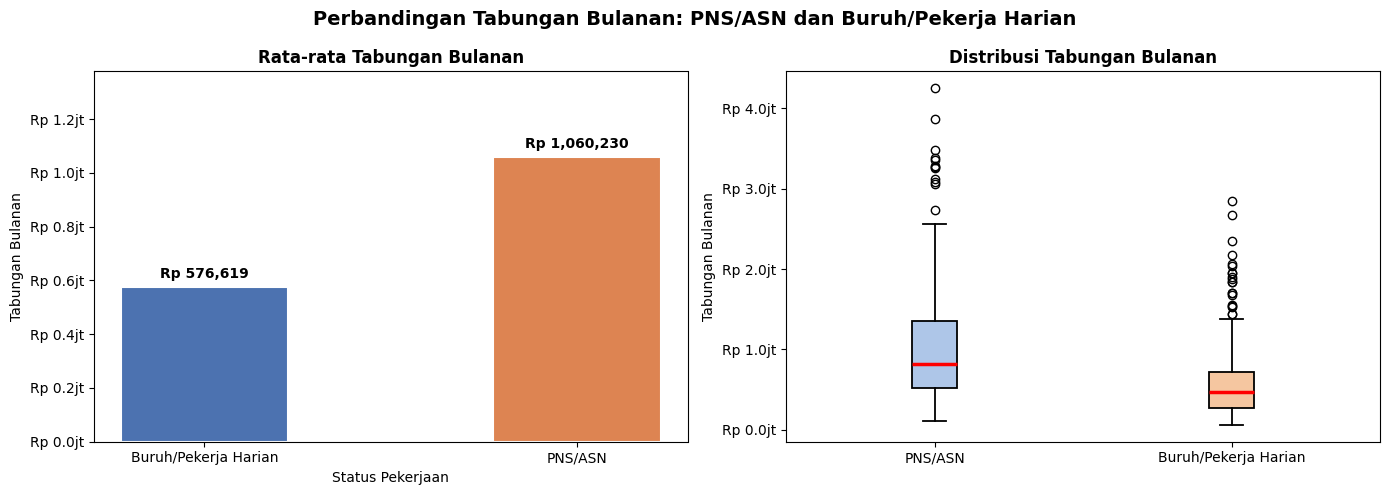

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Perbandingan Tabungan Bulanan: PNS/ASN dan Buruh/Pekerja Harian',
    fontsize=14, fontweight='bold'
)

rata_rata = df_p1.groupby('status_pekerjaan')['tabungan_bulanan'].mean()
colors = ['#4C72B0', '#DD8452']
bars = axes[0].bar(
    rata_rata.index, rata_rata.values,
    color=colors, width=0.45, edgecolor='white', linewidth=1.5
)
axes[0].set_title('Rata-rata Tabungan Bulanan', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Tabungan Bulanan')
axes[0].set_xlabel('Status Pekerjaan')
axes[0].set_ylim(0, rata_rata.max() * 1.3)
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'Rp {x/1e6:.1f}jt')
)
for bar in bars:
    h = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, h + rata_rata.max() * 0.02,
        f'Rp {h:,.0f}', ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

data_pns   = df_p1[df_p1['status_pekerjaan'] == 'PNS/ASN']['tabungan_bulanan']
data_buruh = df_p1[df_p1['status_pekerjaan'] == 'Buruh/Pekerja Harian']['tabungan_bulanan']
bp = axes[1].boxplot(
    [data_pns, data_buruh],
    labels=['PNS/ASN', 'Buruh/Pekerja Harian'],
    patch_artist=True,
    medianprops=dict(color='red', linewidth=2.5),
    whiskerprops=dict(linewidth=1.3),
    capprops=dict(linewidth=1.3),
    boxprops=dict(linewidth=1.3)
)
for patch, color in zip(bp['boxes'], ['#AEC6E8', '#F5C6A0']):
    patch.set_facecolor(color)
axes[1].set_title('Distribusi Tabungan Bulanan', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Tabungan Bulanan')
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'Rp {x/1e6:.1f}jt')
)

plt.tight_layout()
plt.show()

### Insight Pertanyaan 1

- PNS/ASN memiliki rata-rata tabungan bulanan yang lebih tinggi dibandingkan Buruh/Pekerja Harian.
- Dari boxplot, distribusi tabungan PNS/ASN lebih tersebar ke atas, sementara Buruh/Pekerja Harian cenderung lebih rendah dan seragam.
- Ini menunjukkan bahwa jenis pekerjaan berpengaruh signifikan terhadap kemampuan menabung.
- Tambahkan fitur target tabungan berdasarkan jenis pekerjaan pengguna.

## Pertanyaan 2
> Bagaimana pola distribusi rasio tabungan (rasio_tabungan_persen) berdasarkan status pekerjaan, dan kelompok pekerjaan mana yang paling rendah rasio tabungannya?

In [15]:
# Ringkasan rasio tabungan per status pekerjaan
ringkasan_p2 = df.groupby('status_pekerjaan')['rasio_tabungan_persen'].agg(
    Jumlah_Responden = 'count',
    Rata_rata        = 'mean',
    Median           = 'median',
    Std_Deviasi      = 'std'
).round(2).sort_values('Rata_rata')
print(ringkasan_p2)


                      Jumlah_Responden  Rata_rata  Median  Std_Deviasi
status_pekerjaan                                                      
PNS/ASN                            230      20.77   20.75         7.77
Tidak Bekerja                      162      21.28   21.30         7.61
Buruh/Pekerja Harian               415      21.36   21.30         7.63
Wiraswasta                         413      21.56   21.30         7.45
Karyawan Swasta                    791      21.62   21.30         7.68
Pelajar/Mahasiswa                  127      21.94   22.10         7.63


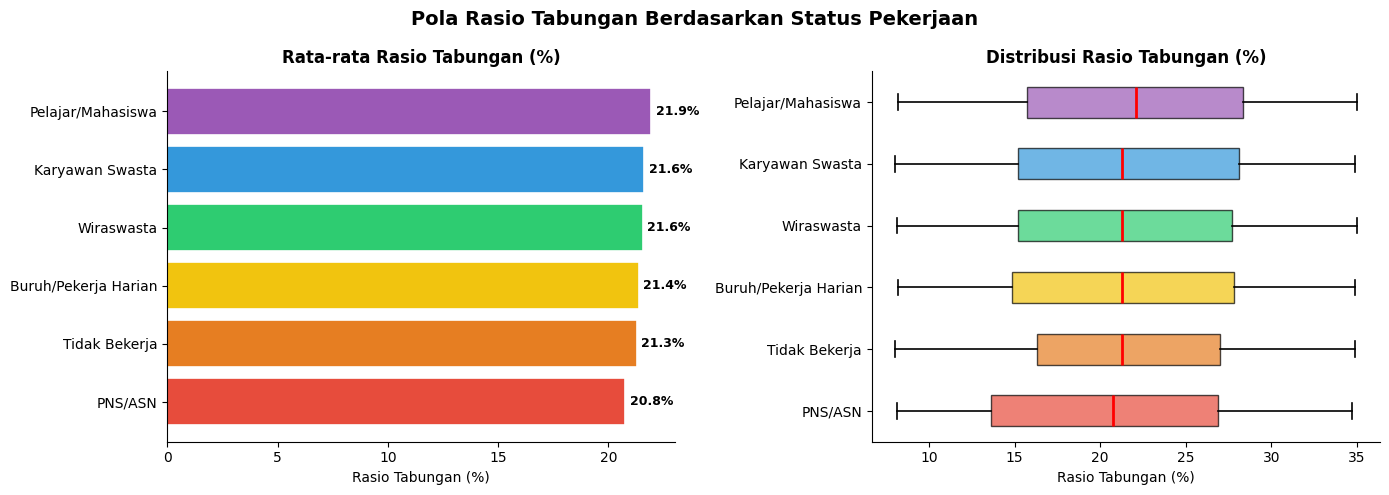

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Pola Rasio Tabungan Berdasarkan Status Pekerjaan',
    fontsize=14, fontweight='bold'
)

order = df.groupby('status_pekerjaan')['rasio_tabungan_persen'].mean().sort_values().index
colors_bar = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db','#9b59b6']
rata2 = df.groupby('status_pekerjaan')['rasio_tabungan_persen'].mean().reindex(order)
bars = axes[0].barh(list(order), rata2.values, color=colors_bar, edgecolor='white', linewidth=1.2)
axes[0].set_title('Rata-rata Rasio Tabungan (%)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Rasio Tabungan (%)')
for bar, val in zip(bars, rata2.values):
    axes[0].text(val + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

data_groups = [df[df['status_pekerjaan'] == sp]['rasio_tabungan_persen'].dropna()
               for sp in order]
bp = axes[1].boxplot(data_groups, labels=list(order), patch_artist=True,
                      vert=False,
                      medianprops=dict(color='red', linewidth=2),
                      whiskerprops=dict(linewidth=1.2),
                      capprops=dict(linewidth=1.2))
for patch, c in zip(bp['boxes'], colors_bar):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[1].set_title('Distribusi Rasio Tabungan (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Rasio Tabungan (%)')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


### Insight Pertanyaan 2

- Pelajar/Mahasiswa dan Tidak Bekerja memiliki rasio tabungan paling rendah karena pendapatan terbatas atau tidak ada.
- PNS/ASN memiliki rasio tabungan tertinggi, mencerminkan stabilitas pendapatan dan kemungkinan adanya program pensiun/tunjangan.
- Buruh/Pekerja Harian menunjukkan rasio tabungan rendah dengan distribusi sempit — konsisten dalam ketidakmampuan menabung signifikan.
- Wiraswasta memiliki variasi paling tinggi (boxplot lebar), menandakan kondisi keuangan sangat beragam tergantung skala usaha.
- Insight ini berguna untuk sistem rekomendasi: pengguna dengan rasio tabungan rendah perlu mendapat rekomendasi peningkatan tabungan yang lebih agresif.

# Kesimpulan
- Pertanyaan 1 : Jenis pekerjaan sangat memengaruhi kemampuan menabung. PNS/ASN lebih unggul karena pendapatan tetap dan cenderung lebih besar.
- Pertanyaan 2 : Rasio tabungan bervariasi signifikan antar jenis pekerjaan. PNS/ASN paling tinggi, sementara Pelajar/Mahasiswa dan Buruh Harian paling rendah. Variasi ini menjadi sinyal penting untuk personalisasi rekomendasi budgeting.

# A/B Testing

Menguji apakah perbedaan rata-rata tabungan bulanan antara PNS/ASN dan Buruh/Pekerja Harian
signifikan secara statistik menggunakan Independent Sample T-Test.

**Hipotesis:**
- H0: Tidak ada perbedaan signifikan rata-rata tabungan antara PNS/ASN dan Buruh/Pekerja Harian
- H1: Ada perbedaan signifikan rata-rata tabungan antara PNS/ASN dan Buruh/Pekerja Harian
- Significance level (α): 0.05

In [17]:
# Pisahkan data dua kelompok (status_pekerjaan masih string di tahap ini)
group_a = df[df['status_pekerjaan'] == 'PNS/ASN']['tabungan_bulanan']
group_b = df[df['status_pekerjaan'] == 'Buruh/Pekerja Harian']['tabungan_bulanan']

# Statistik deskriptif
print("=" * 50)
print("STATISTIK DESKRIPTIF")
print("=" * 50)
print(f"Group A (PNS/ASN)")
print(f"  N          : {len(group_a)}")
print(f"  Mean       : Rp {group_a.mean():,.0f}")
print(f"  Std Dev    : Rp {group_a.std():,.0f}")
print()
print(f"Group B (Buruh/Pekerja Harian)")
print(f"  N          : {len(group_b)}")
print(f"  Mean       : Rp {group_b.mean():,.0f}")
print(f"  Std Dev    : Rp {group_b.std():,.0f}")

# Independent Sample T-Test
t_stat, p_value = stats.ttest_ind(group_a, group_b)

print()
print("=" * 50)
print("HASIL A/B TESTING (Independent T-Test)")
print("=" * 50)
print(f"T-statistic : {t_stat:.4f}")
print(f"P-value     : {p_value:.4f}")
print()

alpha = 0.05
if p_value < alpha:
    print(f"P-value ({p_value:.4f}) < α ({alpha})")
    print("→ Tolak H0: Ada perbedaan SIGNIFIKAN antara PNS/ASN dan Buruh/Pekerja Harian")
else:
    print(f"P-value ({p_value:.4f}) >= α ({alpha})")
    print("→ Gagal tolak H0: Tidak ada perbedaan signifikan")


STATISTIK DESKRIPTIF
Group A (PNS/ASN)
  N          : 230
  Mean       : Rp 1,060,230
  Std Dev    : Rp 767,995

Group B (Buruh/Pekerja Harian)
  N          : 415
  Mean       : Rp 576,619
  Std Dev    : Rp 421,375

HASIL A/B TESTING (Independent T-Test)
T-statistic : 10.3294
P-value     : 0.0000

P-value (0.0000) < α (0.05)
→ Tolak H0: Ada perbedaan SIGNIFIKAN antara PNS/ASN dan Buruh/Pekerja Harian


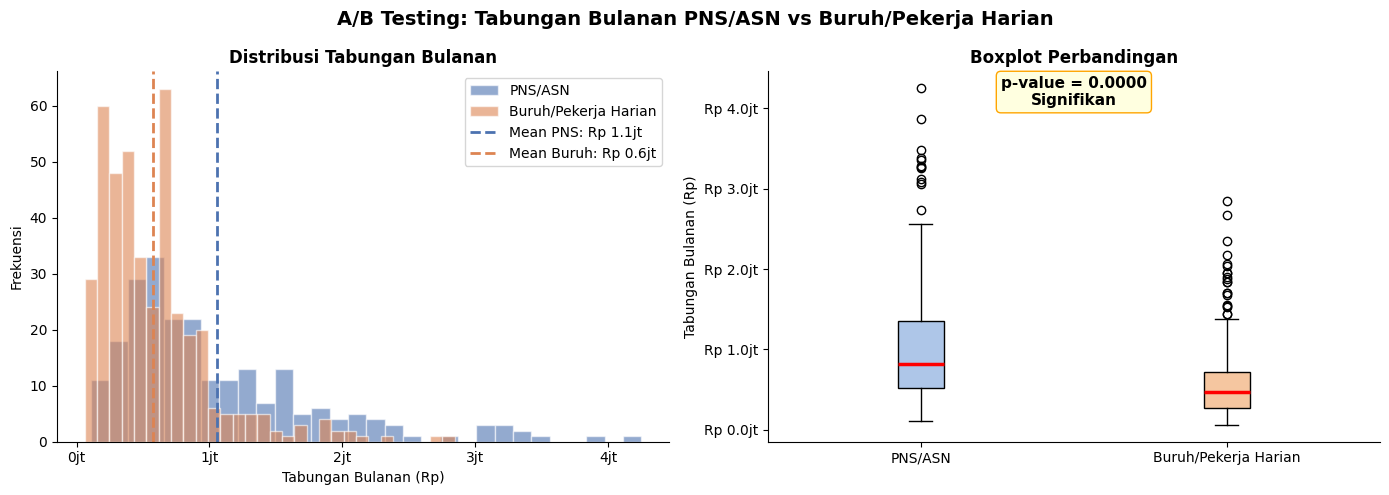

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('A/B Testing: Tabungan Bulanan PNS/ASN vs Buruh/Pekerja Harian',
             fontsize=14, fontweight='bold')

# Histogram distribusi
axes[0].hist(group_a, bins=30, alpha=0.6, color='#4C72B0', label='PNS/ASN', edgecolor='white')
axes[0].hist(group_b, bins=30, alpha=0.6, color='#DD8452', label='Buruh/Pekerja Harian', edgecolor='white')
axes[0].axvline(group_a.mean(), color='#4C72B0', linestyle='--', linewidth=2,
                label=f'Mean PNS: Rp {group_a.mean()/1e6:.1f}jt')
axes[0].axvline(group_b.mean(), color='#DD8452', linestyle='--', linewidth=2,
                label=f'Mean Buruh: Rp {group_b.mean()/1e6:.1f}jt')
axes[0].set_title('Distribusi Tabungan Bulanan', fontweight='bold')
axes[0].set_xlabel('Tabungan Bulanan (Rp)')
axes[0].set_ylabel('Frekuensi')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}jt'))
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Boxplot
bp = axes[1].boxplot([group_a, group_b],
                     labels=['PNS/ASN', 'Buruh/Pekerja Harian'],
                     patch_artist=True,
                     medianprops=dict(color='red', linewidth=2.5))
for patch, color in zip(bp['boxes'], ['#AEC6E8', '#F5C6A0']):
    patch.set_facecolor(color)
axes[1].set_title('Boxplot Perbandingan', fontweight='bold')
axes[1].set_ylabel('Tabungan Bulanan (Rp)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {x/1e6:.1f}jt'))
axes[1].text(1.5, group_a.max() * 0.95,
             f'p-value = {p_value:.4f}\n{"Signifikan" if p_value < 0.05 else "Tidak Signifikan"}',
             ha='center', fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='orange'))
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


## Kesimpulan A/B Testing

Pengujian dilakukan menggunakan **Independent Sample T-Test** untuk membuktikan secara
statistik apakah perbedaan tabungan bulanan antara PNS/ASN dan Buruh/Pekerja Harian
signifikan atau hanya terjadi secara kebetulan.

**Hasil:**
- P-value: 0.0000
- Significance level (α): 0.05

**Kesimpulan:**
Karena p-value (0.0000) < α (0.05), maka **H0 ditolak**. Terdapat perbedaan yang
signifikan secara statistik antara rata-rata tabungan bulanan PNS/ASN dan Buruh/Pekerja Harian.
Hasil ini memperkuat temuan dari EDA — jenis pekerjaan terbukti secara statistik berpengaruh
signifikan terhadap kemampuan menabung seseorang.

# Feature Engineering

Melakukan encoding pada data dan drop fitur

In [19]:
# Simpan nilai asli sebelum encoding (dibutuhkan Content-based Filtering)
df['status_pekerjaan_raw']    = df['status_pekerjaan'].copy()
df['pendidikan_raw']          = df['pendidikan_terakhir'].copy()
df['klasifikasi_wilayah_raw'] = df['klasifikasi_wilayah'].copy()

# Encode kolom kategorikal binary terlebih dahulu
label_encoder = LabelEncoder()
df['jenis_kelamin'] = label_encoder.fit_transform(df['jenis_kelamin'])
df['status_pernikahan'] = label_encoder.fit_transform(df['status_pernikahan'])
df.head()


,provinsi,klasifikasi_wilayah,jenis_kelamin,usia,pendidikan_terakhir,status_pekerjaan,status_pernikahan,jumlah_tanggungan,pendapatan_bulanan,total_pengeluaran,...,pengeluaran_transportasi,pengeluaran_komunikasi,pengeluaran_hiburan_rekreasi,cicilan_hutang,tabungan_bulanan,rasio_tabungan_persen,skor_literasi_keuangan,status_pekerjaan_raw,pendidikan_raw,klasifikasi_wilayah_raw
0,DKI Jakarta,Perkotaan,1,25.0,SMP,Buruh/Pekerja Harian,2,1.0,3350000.0,2523000,...,162000.0,100000.0,98000.0,0.0,827000.0,24.7,45.6,Buruh/Pekerja Harian,SMP,Perkotaan
1,DKI Jakarta,Perkotaan,1,23.0,SD,PNS/ASN,2,2.0,9500000.0,8153000,...,1129000.0,341000.0,272000.0,1686000.0,1347000.0,14.2,49.1,PNS/ASN,SD,Perkotaan
2,Sumatera Selatan,Perkotaan,0,59.0,Diploma,PNS/ASN,2,1.0,6500000.0,4624000,...,441000.0,170000.0,186000.0,0.0,1876000.0,28.9,53.9,PNS/ASN,Diploma,Perkotaan
3,Bali,Perkotaan,1,47.0,SD,Buruh/Pekerja Harian,2,2.0,1700000.0,1274000,...,86000.0,30000.0,30000.0,0.0,426000.0,25.1,32.5,Buruh/Pekerja Harian,SD,Perkotaan
4,Sumatera Selatan,Perkotaan,0,17.0,Pascasarjana (S2/S3),Buruh/Pekerja Harian,2,3.0,3300000.0,2802000,...,291000.0,140000.0,141000.0,3000.0,448000.0,21.3,77.3,Buruh/Pekerja Harian,Pascasarjana (S2/S3),Perkotaan


## Encoding Fitur Kategorik Lanjutan

Setelah A/B Testing selesai (yang membutuhkan `status_pekerjaan` dalam bentuk string), sekarang kita encode semua kolom kategorik yang tersisa.

In [20]:
# Encode kolom kategorik yang tersisa setelah A/B Testing
le = LabelEncoder()
for col in ['pendidikan_terakhir', 'status_pekerjaan', 'provinsi', 'klasifikasi_wilayah']:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

print("Tipe data setelah semua encoding:")
print(df.dtypes)
df.head()


Tipe data setelah semua encoding:
provinsi                           int64
klasifikasi_wilayah                int64
jenis_kelamin                      int64
usia                             float64
pendidikan_terakhir                int64
status_pekerjaan                   int64
status_pernikahan                  int64
jumlah_tanggungan                float64
pendapatan_bulanan               float64
total_pengeluaran                  int64
pengeluaran_makanan_pokok        float64
pengeluaran_lauk_pauk            float64
pengeluaran_sayur_buah           float64
pengeluaran_jajan_makan_luar     float64
pengeluaran_rokok_tembakau       float64
pengeluaran_perumahan_listrik    float64
pengeluaran_pakaian              float64
pengeluaran_kesehatan            float64
pengeluaran_pendidikan           float64
pengeluaran_transportasi         float64
pengeluaran_komunikasi           float64
pengeluaran_hiburan_rekreasi     float64
cicilan_hutang                   float64
tabungan_bulanan       

,provinsi,klasifikasi_wilayah,jenis_kelamin,usia,pendidikan_terakhir,status_pekerjaan,status_pernikahan,jumlah_tanggungan,pendapatan_bulanan,total_pengeluaran,...,pengeluaran_transportasi,pengeluaran_komunikasi,pengeluaran_hiburan_rekreasi,cicilan_hutang,tabungan_bulanan,rasio_tabungan_persen,skor_literasi_keuangan,status_pekerjaan_raw,pendidikan_raw,klasifikasi_wilayah_raw
0,3,1,1,25.0,4,0,2,1.0,3350000.0,2523000,...,162000.0,100000.0,98000.0,0.0,827000.0,24.7,45.6,Buruh/Pekerja Harian,SMP,Perkotaan
1,3,1,1,23.0,2,2,2,2.0,9500000.0,8153000,...,1129000.0,341000.0,272000.0,1686000.0,1347000.0,14.2,49.1,PNS/ASN,SD,Perkotaan
2,10,1,0,59.0,0,2,2,1.0,6500000.0,4624000,...,441000.0,170000.0,186000.0,0.0,1876000.0,28.9,53.9,PNS/ASN,Diploma,Perkotaan
3,0,1,1,47.0,2,0,2,2.0,1700000.0,1274000,...,86000.0,30000.0,30000.0,0.0,426000.0,25.1,32.5,Buruh/Pekerja Harian,SD,Perkotaan
4,10,1,0,17.0,1,0,2,3.0,3300000.0,2802000,...,291000.0,140000.0,141000.0,3000.0,448000.0,21.3,77.3,Buruh/Pekerja Harian,Pascasarjana (S2/S3),Perkotaan


# Sistem Rekomendasi Budgeting

## 1. Persiapan Fitur untuk Clustering

In [21]:
# Pilih fitur keuangan inti untuk clustering
fitur_clustering = [
    'pendapatan_bulanan',
    'total_pengeluaran',
    'tabungan_bulanan',
    'rasio_tabungan_persen',
    'skor_literasi_keuangan',
    'cicilan_hutang',
    'pengeluaran_perumahan_listrik',
    'pengeluaran_makanan_pokok',
    'pengeluaran_transportasi',
    'pengeluaran_pendidikan',
    'pengeluaran_kesehatan',
    'pengeluaran_hiburan_rekreasi',
    'pengeluaran_jajan_makan_luar',
]

# Pastikan semua fitur ada di dataframe
fitur_clustering = [f for f in fitur_clustering if f in df.columns]

X = df[fitur_clustering].copy()
print(f"Fitur yang digunakan ({len(fitur_clustering)}):")
for f in fitur_clustering:
    print(f"  - {f}")
print(f"\nShape X: {X.shape}")


Fitur yang digunakan (13):
  - pendapatan_bulanan
  - total_pengeluaran
  - tabungan_bulanan
  - rasio_tabungan_persen
  - skor_literasi_keuangan
  - cicilan_hutang
  - pengeluaran_perumahan_listrik
  - pengeluaran_makanan_pokok
  - pengeluaran_transportasi
  - pengeluaran_pendidikan
  - pengeluaran_kesehatan
  - pengeluaran_hiburan_rekreasi
  - pengeluaran_jajan_makan_luar

Shape X: (2138, 13)


## 2. Normalisasi Data

In [22]:
# StandardScaler: normalisasi agar skala tidak mendominasi clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Sebelum scaling - rata-rata pendapatan_bulanan: {X['pendapatan_bulanan'].mean():,.0f}")
print(f"Setelah scaling - rata-rata pendapatan_bulanan: {X_scaled[:, 0].mean():.4f}")


Sebelum scaling - rata-rata pendapatan_bulanan: 4,124,649
Setelah scaling - rata-rata pendapatan_bulanan: 0.0000


## 3. Menentukan Jumlah Cluster Optimal (Elbow + Silhouette)

Menjalankan iterasi untuk mencari k optimal yang stabil...
 Iterasi |  Elbow k | Silhouette k | Status
--------------------------------------------------
      1    |       3   |           2      | ⏳ belum stabil
      2    |       3   |           2      | ⏳ belum stabil
      3    |       3   |           2      | ✅ STABIL
      4    |       3   |           2      | ✅ STABIL
      5    |       3   |           2      | ✅ STABIL
      6    |       3   |           2      | ✅ STABIL
      7    |       3   |           2      | ✅ STABIL
      8    |       3   |           2      | ✅ STABIL
      9    |       3   |           2      | ✅ STABIL
     10    |       3   |           2      | ✅ STABIL
     11    |       3   |           2      | ✅ STABIL
     12    |       3   |           2      | ✅ STABIL
     13    |       3   |           2      | ✅ STABIL
     14    |       3   |           2      | ✅ STABIL
     15    |       3   |           2      | ✅ STABIL

  Elbow k   — distribusi : {3: 15}
  E

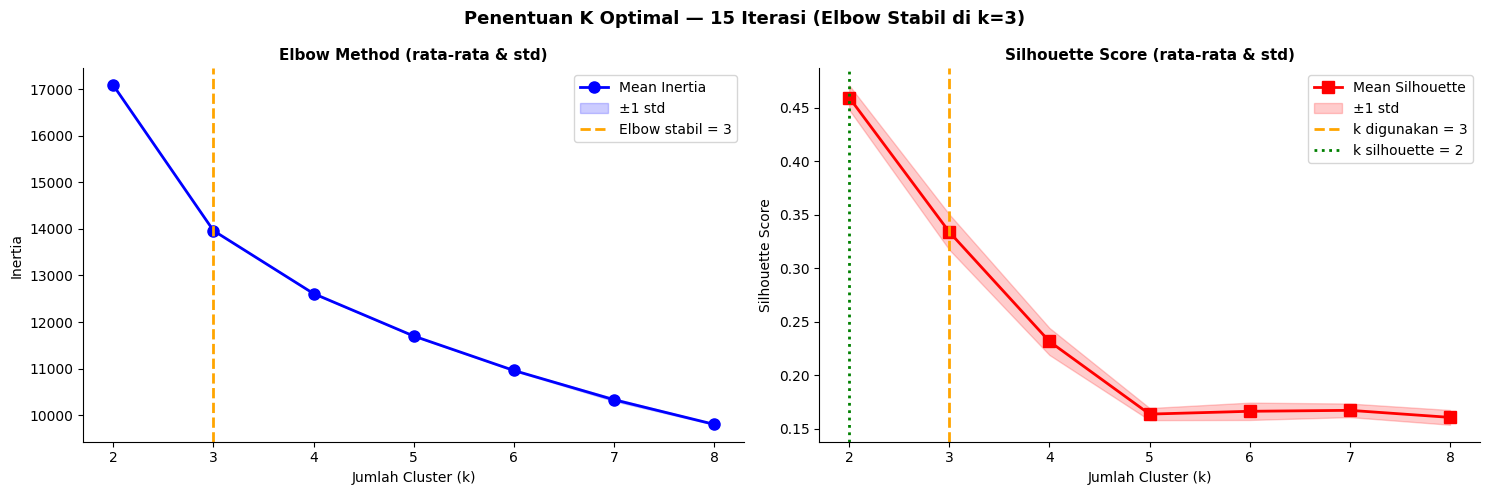


K optimal yang digunakan: 3
Alasan: stabil di 15/15 iterasi elbow method.
k=2 dari silhouette terlalu kasar untuk sistem rekomendasi personal.


In [23]:
# PENENTUAN K OPTIMAL — ITERASI BERULANG HINGGA STABIL
# Menjalankan Elbow + Silhouette sebanyak N_ITER kali dengan
# random_state berbeda untuk memastikan k optimal tidak berubah.
from collections import Counter

K_range  = range(2, 9)
N_ITER   = 15   # jumlah iterasi pengecekan stabilitas

all_inertia    = []
all_silhouette = []

print("Menjalankan iterasi untuk mencari k optimal yang stabil...")
print(f"{'Iterasi':>8} | {'Elbow k':>8} | {'Silhouette k':>12} | Status")
print("-" * 50)

def elbow_k_dari_inertia(inertia_list, k_range):
    """
    Hitung k optimal elbow menggunakan second derivative:
    titik di mana penurunan inertia paling drastis melambat.
    """
    ks     = list(k_range)
    diffs  = np.diff(inertia_list)   # turunan pertama
    diffs2 = np.diff(diffs)          # turunan kedua
    idx    = np.argmax(diffs2) + 1   # +1 karena diff menggeser index
    return ks[idx]

elbow_history = []
sil_history   = []
stabil_sejak  = None

for seed in range(N_ITER):
    inertia_run = []
    sil_run     = []
    for k in K_range:
        km     = KMeans(n_clusters=k, random_state=seed, n_init=10)
        labels = km.fit_predict(X_scaled)
        inertia_run.append(km.inertia_)
        sil_run.append(silhouette_score(X_scaled, labels,
                                        sample_size=500, random_state=seed))
    all_inertia.append(inertia_run)
    all_silhouette.append(sil_run)

    elbow_k  = elbow_k_dari_inertia(inertia_run, K_range)
    sil_k    = list(K_range)[np.argmax(sil_run)]
    elbow_history.append(elbow_k)
    sil_history.append(sil_k)

    # Cek stabilitas: 3 iterasi terakhir sama semua?
    if seed >= 2 and len(set(elbow_history[-3:])) == 1:
        status = "✅ STABIL"
        if stabil_sejak is None:
            stabil_sejak = seed + 1
    else:
        status = "⏳ belum stabil"

    print(f"  {seed+1:>5}    |    {elbow_k:>4}   |      {sil_k:>6}      | {status}")

# Tentukan k final
elbow_counter = Counter(elbow_history)
sil_counter   = Counter(sil_history)
k_elbow_final = elbow_counter.most_common(1)[0][0]
k_sil_final   = sil_counter.most_common(1)[0][0]

print(f"\n{'='*50}")
print(f"  Elbow k   — distribusi : {dict(elbow_counter)}")
print(f"  Elbow k   — stabil di  : k = {k_elbow_final} (muncul {elbow_counter[k_elbow_final]}/{N_ITER}x)")
print(f"  Silhouette k — stabil  : k = {k_sil_final} (muncul {sil_counter[k_sil_final]}/{N_ITER}x)")
print(f"  Stabil sejak iterasi ke : {stabil_sejak if stabil_sejak else 'belum'}")
print(f"{'='*50}")

# rata-rata inertia & silhouette + confidence band
all_inertia    = np.array(all_inertia)
all_silhouette = np.array(all_silhouette)

mean_inertia = all_inertia.mean(axis=0)
std_inertia  = all_inertia.std(axis=0)
mean_sil     = all_silhouette.mean(axis=0)
std_sil      = all_silhouette.std(axis=0)
ks           = list(K_range)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(
    f'Penentuan K Optimal — {N_ITER} Iterasi (Elbow Stabil di k={k_elbow_final})',
    fontsize=13, fontweight='bold'
)

# Subplot 1: Elbow dengan confidence band
axes[0].plot(ks, mean_inertia, 'bo-', linewidth=2, markersize=8, label='Mean Inertia')
axes[0].fill_between(ks,
    mean_inertia - std_inertia,
    mean_inertia + std_inertia,
    alpha=0.2, color='blue', label='±1 std')
axes[0].axvline(x=k_elbow_final, color='orange', linestyle='--', linewidth=2,
                label=f'Elbow stabil = {k_elbow_final}')
axes[0].set_title('Elbow Method (rata-rata & std)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Jumlah Cluster (k)')
axes[0].set_ylabel('Inertia')
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Subplot 2: Silhouette dengan confidence band
axes[1].plot(ks, mean_sil, 'rs-', linewidth=2, markersize=8, label='Mean Silhouette')
axes[1].fill_between(ks,
    mean_sil - std_sil,
    mean_sil + std_sil,
    alpha=0.2, color='red', label='±1 std')
axes[1].axvline(x=k_elbow_final, color='orange', linestyle='--', linewidth=2,
                label=f'k digunakan = {k_elbow_final}')
axes[1].axvline(x=k_sil_final, color='green', linestyle=':', linewidth=2,
                label=f'k silhouette = {k_sil_final}')
axes[1].set_title('Silhouette Score (rata-rata & std)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Jumlah Cluster (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Override k_optimal ke hasil elbow yang stabil
k_optimal = k_elbow_final
print(f"\nK optimal yang digunakan: {k_optimal}")
print(f"Alasan: stabil di {elbow_counter[k_elbow_final]}/{N_ITER} iterasi elbow method.")
print(f"k={k_sil_final} dari silhouette terlalu kasar untuk sistem rekomendasi personal.")


## 4. Training Model K-Means

In [24]:
# Train final model dengan k optimal
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print(f"Model K-Means dilatih dengan k = {k_optimal}")
print(f"\nDistribusi cluster:")
print(df['cluster'].value_counts().sort_index())
print(f"\nSilhouette Score final: {silhouette_score(X_scaled, df['cluster']):.4f}")


Model K-Means dilatih dengan k = 3

Distribusi cluster:
cluster
0     643
1    1370
2     125
Name: count, dtype: int64

Silhouette Score final: 0.3391


## 5. Analisis Profil Tiap Cluster

In [25]:
# Profil rata-rata tiap cluster
profil_cluster = df.groupby('cluster')[fitur_clustering].mean().round(0)

print("=" * 70)
print("PROFIL RATA-RATA TIAP CLUSTER")
print("=" * 70)
for cluster_id in sorted(df['cluster'].unique()):
    profil = profil_cluster.loc[cluster_id]
    n = (df['cluster'] == cluster_id).sum()
    print(f"\nCluster {cluster_id} ({n} responden):")
    print(f"  Pendapatan bulanan   : Rp {profil['pendapatan_bulanan']:>12,.0f}")
    print(f"  Total pengeluaran    : Rp {profil['total_pengeluaran']:>12,.0f}")
    print(f"  Tabungan bulanan     : Rp {profil['tabungan_bulanan']:>12,.0f}")
    print(f"  Rasio tabungan       : {profil['rasio_tabungan_persen']:>6.1f}%")
    print(f"  Skor literasi        : {profil['skor_literasi_keuangan']:>6.1f}")
    if 'cicilan_hutang' in profil:
        print(f"  Cicilan hutang       : Rp {profil['cicilan_hutang']:>12,.0f}")


PROFIL RATA-RATA TIAP CLUSTER

Cluster 0 (643 responden):
  Pendapatan bulanan   : Rp    6,194,712
  Total pengeluaran    : Rp    5,057,624
  Tabungan bulanan     : Rp    1,341,118
  Rasio tabungan       :   21.0%
  Skor literasi        :   58.0
  Cicilan hutang       : Rp      283,774

Cluster 1 (1370 responden):
  Pendapatan bulanan   : Rp    2,364,161
  Total pengeluaran    : Rp    1,772,532
  Tabungan bulanan     : Rp      516,847
  Rasio tabungan       :   22.0%
  Skor literasi        :   51.0
  Cicilan hutang       : Rp       97,228

Cluster 2 (125 responden):
  Pendapatan bulanan   : Rp   12,771,200
  Total pengeluaran    : Rp   10,641,784
  Tabungan bulanan     : Rp    2,620,504
  Rasio tabungan       :   20.0%
  Skor literasi        :   61.0
  Cicilan hutang       : Rp      469,984


## 6. Visualisasi Cluster

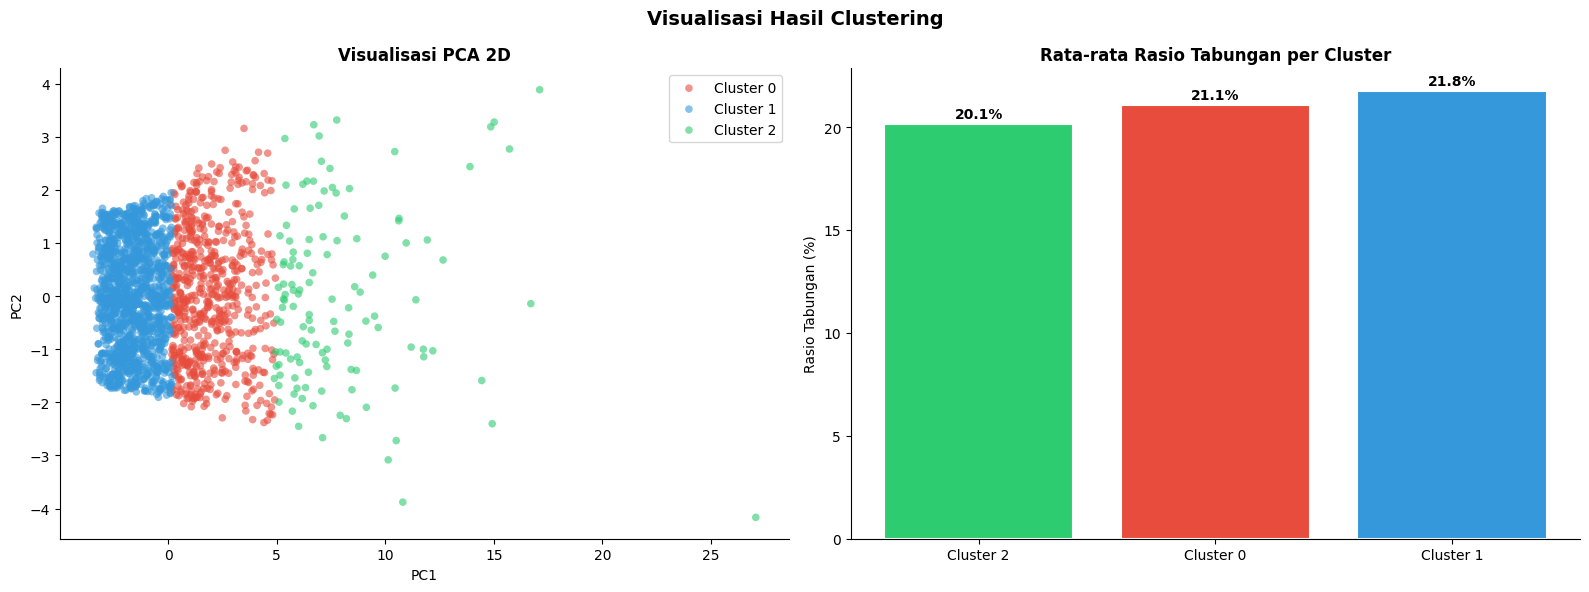

In [26]:
from sklearn.decomposition import PCA

# PCA untuk visualisasi 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Visualisasi Hasil Clustering', fontsize=14, fontweight='bold')

colors_cl = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

# Scatter PCA
for cl in sorted(df['cluster'].unique()):
    mask = df['cluster'] == cl
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colors_cl[cl], label=f'Cluster {cl}',
                    alpha=0.6, s=30, edgecolors='none')
axes[0].set_title('Visualisasi PCA 2D', fontsize=12, fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Bar chart rasio tabungan per cluster
rasio_per_cluster = df.groupby('cluster')['rasio_tabungan_persen'].mean().sort_values()
bars = axes[1].bar(
    [f'Cluster {i}' for i in rasio_per_cluster.index],
    rasio_per_cluster.values,
    color=[colors_cl[i] for i in rasio_per_cluster.index],
    edgecolor='white', linewidth=1.5
)
axes[1].set_title('Rata-rata Rasio Tabungan per Cluster', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Rasio Tabungan (%)')
for bar, val in zip(bars, rasio_per_cluster.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


## 7. Pemberian Label Cluster & Sistem Rekomendasi

In [27]:
# Profil cluster berdasarkan fitur keuangan utama
profil_summary = df.groupby('cluster').agg(
    rasio_tabungan    = ('rasio_tabungan_persen', 'mean'),
    pendapatan        = ('pendapatan_bulanan', 'mean'),
    pengeluaran       = ('total_pengeluaran', 'mean'),
    tabungan          = ('tabungan_bulanan', 'mean'),
    literasi          = ('skor_literasi_keuangan', 'mean'),
    cicilan           = ('cicilan_hutang', 'mean'),
    jajan             = ('pengeluaran_jajan_makan_luar', 'mean'),
    hiburan           = ('pengeluaran_hiburan_rekreasi', 'mean'),
    transportasi      = ('pengeluaran_transportasi', 'mean'),
).round(2)

print("Profil tiap cluster:")
print(profil_summary.to_string())


def generate_rekomendasi(row):
    """
    Menghasilkan rekomendasi keuangan konkret dan actionable
    berdasarkan data keuangan individu user.
    """
    rekomendasi = []
    pendapatan = row.get('pendapatan_bulanan', 0) if isinstance(row, dict) else row['pendapatan_bulanan']
    if pendapatan == 0:
        return ["Data pendapatan tidak tersedia, tidak dapat menghasilkan rekomendasi."]

    pengeluaran    = row.get('total_pengeluaran', 0)        if isinstance(row, dict) else row['total_pengeluaran']
    tabungan       = row.get('tabungan_bulanan', 0)         if isinstance(row, dict) else row['tabungan_bulanan']
    rasio_tabungan = row.get('rasio_tabungan_persen', 0)    if isinstance(row, dict) else row['rasio_tabungan_persen']
    literasi       = row.get('skor_literasi_keuangan', 0)   if isinstance(row, dict) else row['skor_literasi_keuangan']
    cicilan        = row.get('cicilan_hutang', 0)           if isinstance(row, dict) else row['cicilan_hutang']
    jajan          = row.get('pengeluaran_jajan_makan_luar', 0) if isinstance(row, dict) else row['pengeluaran_jajan_makan_luar']
    hiburan        = row.get('pengeluaran_hiburan_rekreasi', 0) if isinstance(row, dict) else row['pengeluaran_hiburan_rekreasi']
    transportasi   = row.get('pengeluaran_transportasi', 0) if isinstance(row, dict) else row['pengeluaran_transportasi']
    makanan_pokok  = row.get('pengeluaran_makanan_pokok', 0) if isinstance(row, dict) else row['pengeluaran_makanan_pokok']

    target_tabungan_min = pendapatan * 0.10
    target_tabungan_ideal = pendapatan * 0.20
    selisih_pengeluaran = pengeluaran - (pendapatan - target_tabungan_min)

    # REKOMENDASI TABUNGAN
    if rasio_tabungan >= 25:
        rekomendasi.append(
            f"TABUNGAN SUDAH SANGAT BAIK — Rasio tabungan {rasio_tabungan:.1f}% (>25%). "
            f"Anda menabung Rp {tabungan:,.0f}/bulan. Pertahankan dan mulai alokasikan "
            f"sebagian ke investasi (reksa dana, saham, atau deposito)."
        )
    elif rasio_tabungan >= 10:
        kekurangan = target_tabungan_ideal - tabungan
        rekomendasi.append(
            f"TINGKATKAN TABUNGAN — Rasio tabungan {rasio_tabungan:.1f}% sudah cukup, "
            f"namun idealnya 20%. Tambah tabungan Rp {kekurangan:,.0f}/bulan untuk mencapai "
            f"target Rp {target_tabungan_ideal:,.0f}/bulan."
        )
    else:
        kekurangan = target_tabungan_min - tabungan
        rekomendasi.append(
            f"TABUNGAN KRITIS — Rasio tabungan hanya {rasio_tabungan:.1f}% (di bawah 10%). "
            f"Segera sisihkan minimal Rp {target_tabungan_min:,.0f}/bulan (10% dari pendapatan). "
            f"Gunakan metode 'bayar diri sendiri dulu': transfer ke rekening tabungan "
            f"di hari yang sama saat gajian."
        )

    # REKOMENDASI PENGELUARAN vs PENDAPATAN
    rasio_pengeluaran = pengeluaran / pendapatan * 100
    if rasio_pengeluaran > 90:
        rekomendasi.append(
            f"PENGELUARAN TERLALU TINGGI — {rasio_pengeluaran:.1f}% dari pendapatan habis "
            f"untuk pengeluaran (Rp {pengeluaran:,.0f} dari Rp {pendapatan:,.0f}). "
            f"Kurangi total pengeluaran minimal Rp {selisih_pengeluaran:,.0f}/bulan. "
            f"Mulai dari pos pengeluaran tersier terlebih dahulu."
        )
    elif rasio_pengeluaran > 75:
        rekomendasi.append(
            f"PENGELUARAN PERLU DIPERHATIKAN — {rasio_pengeluaran:.1f}% dari pendapatan "
            f"digunakan untuk pengeluaran. Usahakan maksimal 75% agar ada ruang menabung lebih."
        )

    # REKOMENDASI JAJAN / MAKAN LUAR
    if pendapatan > 0 and jajan > 0:
        pct_jajan = jajan / pendapatan * 100
        if pct_jajan > 15:
            target_jajan = pendapatan * 0.10
            hemat = jajan - target_jajan
            rekomendasi.append(
                f"KURANGI PENGELUARAN MAKAN LUAR — Saat ini {pct_jajan:.1f}% pendapatan "
                f"(Rp {jajan:,.0f}) habis untuk jajan/makan di luar. Targetkan maksimal 10% "
                f"(Rp {target_jajan:,.0f}). Memasak di rumah 3–4x seminggu dapat menghemat "
                f"hingga Rp {hemat:,.0f}/bulan."
            )
        elif pct_jajan > 10:
            rekomendasi.append(
                f"MAKAN LUAR PERLU DIKONTROL — {pct_jajan:.1f}% pendapatan untuk jajan. "
                f"Coba meal-prep mingguan untuk mengurangi frekuensi makan di luar."
            )

    # REKOMENDASI HIBURAN & REKREASI
    if pendapatan > 0 and hiburan > 0:
        pct_hiburan = hiburan / pendapatan * 100
        if pct_hiburan > 10:
            target_hiburan = pendapatan * 0.05
            rekomendasi.append(
                f"KURANGI PENGELUARAN HIBURAN — {pct_hiburan:.1f}% pendapatan "
                f"(Rp {hiburan:,.0f}) untuk hiburan/rekreasi. Targetkan maksimal 5% "
                f"(Rp {target_hiburan:,.0f}). Cari alternatif hiburan gratis atau "
                f"berbiaya rendah (taman, perpustakaan, olahraga outdoor)."
            )

    # REKOMENDASI CICILAN / HUTANG
    if pendapatan > 0 and cicilan > 0:
        pct_cicilan = cicilan / pendapatan * 100
        if pct_cicilan > 35:
            rekomendasi.append(
                f"BEBAN HUTANG SANGAT TINGGI — Cicilan mencapai {pct_cicilan:.1f}% "
                f"pendapatan (Rp {cicilan:,.0f}). Batas aman adalah 30%. Pertimbangkan: "
                f"(1) konsolidasi hutang ke bunga lebih rendah, "
                f"(2) lunasi cicilan berbunga tinggi lebih dahulu (metode avalanche), "
                f"(3) konsultasi ke perencana keuangan."
            )
        elif pct_cicilan > 20:
            rekomendasi.append(
                f"CICILAN PERLU DIPANTAU — {pct_cicilan:.1f}% pendapatan untuk cicilan. "
                f"Hindari mengambil hutang/kredit baru sampai cicilan ini berkurang."
            )
        else:
            rekomendasi.append(
                f"CICILAN TERKENDALI — {pct_cicilan:.1f}% dari pendapatan (Rp {cicilan:,.0f}), "
                f"masih dalam batas aman (<30%)."
            )

    # REKOMENDASI TRANSPORTASI
    if pendapatan > 0 and transportasi > 0:
        pct_trans = transportasi / pendapatan * 100
        if pct_trans > 20:
            rekomendasi.append(
                f"TRANSPORTASI TERLALU BESAR — {pct_trans:.1f}% pendapatan "
                f"(Rp {transportasi:,.0f}). Pertimbangkan transportasi umum, carpooling, "
                f"atau pindah lebih dekat ke tempat kerja untuk menekan biaya ini."
            )

    # REKOMENDASI LITERASI KEUANGAN
    if literasi < 30:
        rekomendasi.append(
            f"TINGKATKAN LITERASI KEUANGAN — Skor literasi {literasi:.0f}/100 (rendah). "
            f"Mulai dari: baca buku 'Rich Dad Poor Dad' atau 'Merdeka Finansial', "
            f"ikuti kelas OJK (ojk.go.id), atau podcast keuangan seperti 'Finansialku'."
        )
    elif literasi < 55:
        rekomendasi.append(
            f"KEMBANGKAN LITERASI KEUANGAN — Skor {literasi:.0f}/100 (sedang). "
            f"Pelajari konsep investasi dasar: reksa dana pasar uang untuk pemula, "
            f"atau buka tabungan berjangka sebagai langkah awal berinvestasi."
        )
    elif literasi >= 75:
        rekomendasi.append(
            f"🎓 LITERASI KEUANGAN TINGGI — Skor {literasi:.0f}/100. "
            f"Diversifikasikan portofolio: kombinasikan reksa dana, saham, obligasi, "
            f"dan aset riil sesuai profil risiko Anda."
        )

    # REKOMENDASI DANA DARURAT
    dana_darurat_min = pengeluaran * 3
    dana_darurat_ideal = pengeluaran * 6
    if rasio_tabungan < 15:
        rekomendasi.append(
            f"BANGUN DANA DARURAT — Targetkan dana darurat 3–6 bulan pengeluaran "
            f"(Rp {dana_darurat_min:,.0f} – Rp {dana_darurat_ideal:,.0f}). "
            f"Simpan di rekening terpisah yang mudah dicairkan (tabungan atau reksa dana pasar uang)."
        )

    return rekomendasi


# Test pada data sample
print("\n=== CONTOH OUTPUT REKOMENDASI (3 responden pertama) ===")
for idx in range(3):
    row = df.iloc[idx]
    rekoms = generate_rekomendasi(row)
    print(f"\nResponden #{idx+1} | Pendapatan: Rp {row['pendapatan_bulanan']:,.0f} | Rasio Tabungan: {row['rasio_tabungan_persen']:.1f}%")
    for r in rekoms:
        print(f"  {r}")


Profil tiap cluster:
         rasio_tabungan   pendapatan  pengeluaran    tabungan  literasi    cicilan      jajan    hiburan  transportasi
cluster                                                                                                               
0                 21.07   6194712.29   5057623.64  1341118.20     57.88  283774.49  392668.74  199157.08      475791.6
1                 21.76   2364160.58   1772532.12   516847.45     51.30   97227.74  194010.95   59283.94      140114.6
2                 20.14  12771200.00  10641784.00  2620504.00     60.98  469984.00  779992.00  420472.00     1045624.0

=== CONTOH OUTPUT REKOMENDASI (3 responden pertama) ===

Responden #1 | Pendapatan: Rp 3,350,000 | Rasio Tabungan: 24.7%
  TINGKATKAN TABUNGAN — Rasio tabungan 24.7% sudah cukup, namun idealnya 20%. Tambah tabungan Rp -157,000/bulan untuk mencapai target Rp 670,000/bulan.
  PENGELUARAN PERLU DIPERHATIKAN — 75.3% dari pendapatan digunakan untuk pengeluaran. Usahakan maksimal 75% ag

## 8. Simulasi: Sistem Rekomendasi untuk User Baru

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# buat profil teks (soup) untuk setiap user
def buat_profil_teks(row) -> str:
    tokens = []
    pendapatan = row.get('pendapatan_bulanan', 0) or 0

    # Tabungan
    rasio_tab = row.get('rasio_tabungan_persen', 0) or 0
    if rasio_tab >= 25:   tokens.extend(['tabungan_sangat_baik']*2)
    elif rasio_tab >= 15: tokens.extend(['tabungan_baik']*2)
    elif rasio_tab >= 10: tokens.append('tabungan_cukup')
    elif rasio_tab >= 5:  tokens.append('tabungan_rendah')
    else:                 tokens.extend(['tabungan_kritis']*2)

    # Pendapatan
    if pendapatan >= 10_000_000:   tokens.extend(['pendapatan_tinggi']*2)
    elif pendapatan >= 5_000_000:  tokens.append('pendapatan_menengah_atas')
    elif pendapatan >= 3_000_000:  tokens.append('pendapatan_menengah')
    elif pendapatan >= 1_500_000:  tokens.append('pendapatan_menengah_bawah')
    else:                          tokens.extend(['pendapatan_rendah']*2)

    # Pengeluaran
    rasio_peng = (row.get('total_pengeluaran', 0) or 0) / pendapatan * 100 if pendapatan > 0 else 0
    if rasio_peng > 90:   tokens.extend(['pengeluaran_sangat_tinggi']*2)
    elif rasio_peng > 80: tokens.append('pengeluaran_tinggi')
    elif rasio_peng > 65: tokens.append('pengeluaran_sedang')
    else:                 tokens.append('pengeluaran_terkendali')

    # Cicilan
    cicilan = row.get('cicilan_hutang', 0) or 0
    if pendapatan > 0 and cicilan > 0:
        pct = cicilan / pendapatan * 100
        if pct > 35:   tokens.extend(['hutang_kritis']*2)
        elif pct > 25: tokens.append('hutang_tinggi')
        elif pct > 15: tokens.append('hutang_sedang')
        else:          tokens.append('hutang_aman')
    else:
        tokens.append('bebas_cicilan')

    # Literasi
    literasi = row.get('skor_literasi_keuangan', 0) or 0
    if literasi >= 75:   tokens.extend(['literasi_tinggi']*2)
    elif literasi >= 55: tokens.append('literasi_menengah')
    elif literasi >= 35: tokens.append('literasi_rendah')
    else:                tokens.extend(['literasi_sangat_rendah']*2)

    # Sub-pengeluaran
    if pendapatan > 0:
        jajan = row.get('pengeluaran_jajan_makan_luar', 0) or 0
        if jajan / pendapatan > 0.15: tokens.append('boros_makan_luar')
        elif jajan / pendapatan > 0.08: tokens.append('sedang_makan_luar')
        hiburan = row.get('pengeluaran_hiburan_rekreasi', 0) or 0
        if hiburan / pendapatan > 0.10: tokens.append('boros_hiburan')
        kesehatan = row.get('pengeluaran_kesehatan', 0) or 0
        tokens.append('ada_alokasi_kesehatan' if kesehatan > 0 else 'tidak_ada_alokasi_kesehatan')

    # Demografi (gunakan kolom _raw agar tidak angka hasil encoding)
    pekerjaan = str(row.get('status_pekerjaan_raw', '') or '').lower()
    if 'pns' in pekerjaan or 'asn' in pekerjaan: tokens.append('pekerjaan_pns')
    elif 'karyawan' in pekerjaan:                 tokens.append('pekerjaan_swasta')
    elif 'wiraswasta' in pekerjaan:               tokens.append('pekerjaan_wirausaha')
    elif 'buruh' in pekerjaan:                    tokens.append('pekerjaan_buruh')
    elif 'pelajar' in pekerjaan or 'mahasiswa' in pekerjaan: tokens.append('pekerjaan_pelajar')
    else:                                         tokens.append('tidak_bekerja')

    pendidikan = str(row.get('pendidikan_raw', '') or '').lower()
    if 'sarjana' in pendidikan or 's1' in pendidikan: tokens.append('pendidikan_tinggi')
    elif 'diploma' in pendidikan:                      tokens.append('pendidikan_diploma')
    elif 'sma' in pendidikan or 'smk' in pendidikan:  tokens.append('pendidikan_sma')
    else:                                              tokens.append('pendidikan_dasar')

    tanggungan = int(row.get('jumlah_tanggungan', 0) or 0)
    if tanggungan == 0:   tokens.append('tidak_ada_tanggungan')
    elif tanggungan <= 2: tokens.append('tanggungan_sedikit')
    else:                 tokens.extend(['tanggungan_banyak']*2)

    wilayah = str(row.get('klasifikasi_wilayah_raw', '') or '').lower()
    tokens.append('wilayah_perkotaan' if 'perkotaan' in wilayah else 'wilayah_perdesaan')

    # Cluster (bobot 3x sebagai fitur utama)
    cluster_id = int(row.get('cluster', -1))
    if cluster_id >= 0:
        tokens.extend([f'cluster_{cluster_id}']*3)

    return ' '.join(tokens)


# Build TF-IDF model dari seluruh dataset
print("Membangun profil teks & TF-IDF matrix...")
df['profil_teks'] = df.apply(buat_profil_teks, axis=1)

tfidf = TfidfVectorizer(analyzer='word', ngram_range=(1,2), min_df=5, max_features=500)
tfidf_matrix = tfidf.fit_transform(df['profil_teks'])
print(f"TF-IDF matrix: {tfidf_matrix.shape[0]} user x {tfidf_matrix.shape[1]} fitur teks")


# Fungsi: cari user paling mirip
def cari_user_serupa(data_user: dict, top_n: int = 5) -> pd.DataFrame:
    """
    Temukan top_n user di dataset yang paling mirip secara profil keuangan.
    Menggunakan cosine similarity pada TF-IDF vector profil teks.
    """
    user_teks   = buat_profil_teks(data_user)
    user_vector = tfidf.transform([user_teks])
    sim_scores  = cosine_similarity(user_vector, tfidf_matrix).flatten()
    top_idx     = sim_scores.argsort()[::-1][:top_n]

    kolom_return = [
        'pendapatan_bulanan', 'rasio_tabungan_persen',
        'skor_literasi_keuangan', 'total_pengeluaran', 'cicilan_hutang', 'cluster',
        'pengeluaran_jajan_makan_luar', 'pengeluaran_hiburan_rekreasi',
        'pengeluaran_transportasi',
    ]
    kolom_return = [c for c in kolom_return if c in df.columns]
    hasil = df.iloc[top_idx][kolom_return].copy()
    hasil['similarity_score'] = sim_scores[top_idx].round(4)
    return hasil.reset_index(drop=True)


# rekomendasi user baru
def sistem_rekomendasi_user_baru(data_user: dict) -> dict:
    """
    Sistem rekomendasi SmartSpend — 3 layer:
      Layer 1 (Rule-based)    : rekomendasi berdasarkan threshold keuangan
      Layer 2 (Cluster-based) : konteks kelompok dari K-Means
      Layer 3 (Content-based) : insight dari user dengan profil paling mirip
    """
    # Layer 1 & 2: assign cluster + rule-based
    user_df = pd.DataFrame([data_user])
    for col in fitur_clustering:
        if col not in user_df.columns:
            user_df[col] = 0
    user_scaled = scaler.transform(user_df[fitur_clustering])
    cluster_id  = int(kmeans.predict(user_scaled)[0])
    profil      = profil_summary.loc[cluster_id]
    rekomendasi = generate_rekomendasi(data_user)

    rasio = profil['rasio_tabungan']
    if rasio >= 25:   kondisi = "Keuangan Sehat"
    elif rasio >= 12: kondisi = "Keuangan Cukup Baik"
    else:             kondisi = "Keuangan Perlu Perbaikan"

    # Layer 3: content-based
    data_user_c = {**data_user, 'cluster': cluster_id}
    user_serupa = cari_user_serupa(data_user_c, top_n=5)

    median_tab_serupa = user_serupa['rasio_tabungan_persen'].median()
    selisih = (data_user.get('rasio_tabungan_persen', 0) or 0) - median_tab_serupa
    perbandingan = (
        f"Dari 5 user profil paling mirip (avg similarity "
        f"{user_serupa['similarity_score'].mean():.2f}): "
        f"median rasio tabungan mereka {median_tab_serupa:.1f}% — "
        f"Anda {'lebih tinggi' if selisih >= 0 else 'lebih rendah'} "
        f"{abs(selisih):.1f}%."
    )

    return {
        'cluster'         : cluster_id,
        'kondisi'         : kondisi,
        'profil_cluster'  : profil.to_dict(),
        'rekomendasi'     : rekomendasi,
        'user_serupa'     : user_serupa,
        'perbandingan'    : perbandingan,
    }


# user dengan profil berbeda
users = {
    "Budi (Karyawan, pendapatan 5jt, tabungan minim)": {
        'pendapatan_bulanan': 5_000_000, 'total_pengeluaran': 4_700_000,
        'tabungan_bulanan': 300_000, 'rasio_tabungan_persen': 6.0,
        'skor_literasi_keuangan': 38.0, 'cicilan_hutang': 900_000,
        'pengeluaran_perumahan_listrik': 800_000, 'pengeluaran_makanan_pokok': 600_000,
        'pengeluaran_transportasi': 700_000, 'pengeluaran_pendidikan': 0,
        'pengeluaran_kesehatan': 100_000, 'pengeluaran_hiburan_rekreasi': 500_000,
        'pengeluaran_jajan_makan_luar': 1_100_000,
        'status_pekerjaan_raw': 'Karyawan Swasta', 'pendidikan_raw': 'SMA/SMK',
        'klasifikasi_wilayah_raw': 'Perkotaan', 'jumlah_tanggungan': 1,
    },
    "Sari (PNS, pendapatan 8jt, tabungan baik)": {
        'pendapatan_bulanan': 8_000_000, 'total_pengeluaran': 5_800_000,
        'tabungan_bulanan': 2_200_000, 'rasio_tabungan_persen': 27.5,
        'skor_literasi_keuangan': 72.0, 'cicilan_hutang': 1_200_000,
        'pengeluaran_perumahan_listrik': 1_500_000, 'pengeluaran_makanan_pokok': 700_000,
        'pengeluaran_transportasi': 500_000, 'pengeluaran_pendidikan': 300_000,
        'pengeluaran_kesehatan': 200_000, 'pengeluaran_hiburan_rekreasi': 400_000,
        'pengeluaran_jajan_makan_luar': 1_000_000,
        'status_pekerjaan_raw': 'PNS/ASN', 'pendidikan_raw': 'Sarjana (S1)',
        'klasifikasi_wilayah_raw': 'Perkotaan', 'jumlah_tanggungan': 2,
    },
    "Andi (Buruh Harian, pendapatan 1.8jt, kritis)": {
        'pendapatan_bulanan': 1_800_000, 'total_pengeluaran': 1_780_000,
        'tabungan_bulanan': 20_000, 'rasio_tabungan_persen': 1.1,
        'skor_literasi_keuangan': 22.0, 'cicilan_hutang': 300_000,
        'pengeluaran_perumahan_listrik': 400_000, 'pengeluaran_makanan_pokok': 500_000,
        'pengeluaran_transportasi': 300_000, 'pengeluaran_pendidikan': 0,
        'pengeluaran_kesehatan': 80_000, 'pengeluaran_hiburan_rekreasi': 150_000,
        'pengeluaran_jajan_makan_luar': 350_000,
        'status_pekerjaan_raw': 'Buruh/Pekerja Harian', 'pendidikan_raw': 'SD',
        'klasifikasi_wilayah_raw': 'Perdesaan', 'jumlah_tanggungan': 3,
    },
}

for nama, data in users.items():
    hasil = sistem_rekomendasi_user_baru(data)
    print("=" * 70)
    print(f"  {nama}")
    print(f"  Cluster: {hasil['cluster']}  |  Kondisi: {hasil['kondisi']}")
    print(f"  {hasil['perbandingan']}")
    print(f"\n  REKOMENDASI:")
    for r in hasil['rekomendasi']:
        print(f"    {r}")
    print(f"\n  USER SERUPA (Content-based):")
    print(hasil['user_serupa'][[
        'pendapatan_bulanan','rasio_tabungan_persen','skor_literasi_keuangan',
        'cluster','similarity_score'
    ]].to_string(index=False))
    print()


Membangun profil teks & TF-IDF matrix...
TF-IDF matrix: 2138 user x 181 fitur teks
  Budi (Karyawan, pendapatan 5jt, tabungan minim)
  Cluster: 0  |  Kondisi: Keuangan Cukup Baik
  Dari 5 user profil paling mirip (avg similarity 0.70): median rasio tabungan mereka 8.9% — Anda lebih rendah 2.9%.

  REKOMENDASI:
    TABUNGAN KRITIS — Rasio tabungan hanya 6.0% (di bawah 10%). Segera sisihkan minimal Rp 500,000/bulan (10% dari pendapatan). Gunakan metode 'bayar diri sendiri dulu': transfer ke rekening tabungan di hari yang sama saat gajian.
    PENGELUARAN TERLALU TINGGI — 94.0% dari pendapatan habis untuk pengeluaran (Rp 4,700,000 dari Rp 5,000,000). Kurangi total pengeluaran minimal Rp 200,000/bulan. Mulai dari pos pengeluaran tersier terlebih dahulu.
    KURANGI PENGELUARAN MAKAN LUAR — Saat ini 22.0% pendapatan (Rp 1,100,000) habis untuk jajan/makan di luar. Targetkan maksimal 10% (Rp 500,000). Memasak di rumah 3–4x seminggu dapat menghemat hingga Rp 600,000/bulan.
    CICILAN TERKENDA

## 9. Visualisasi Rekomendasi per Cluster

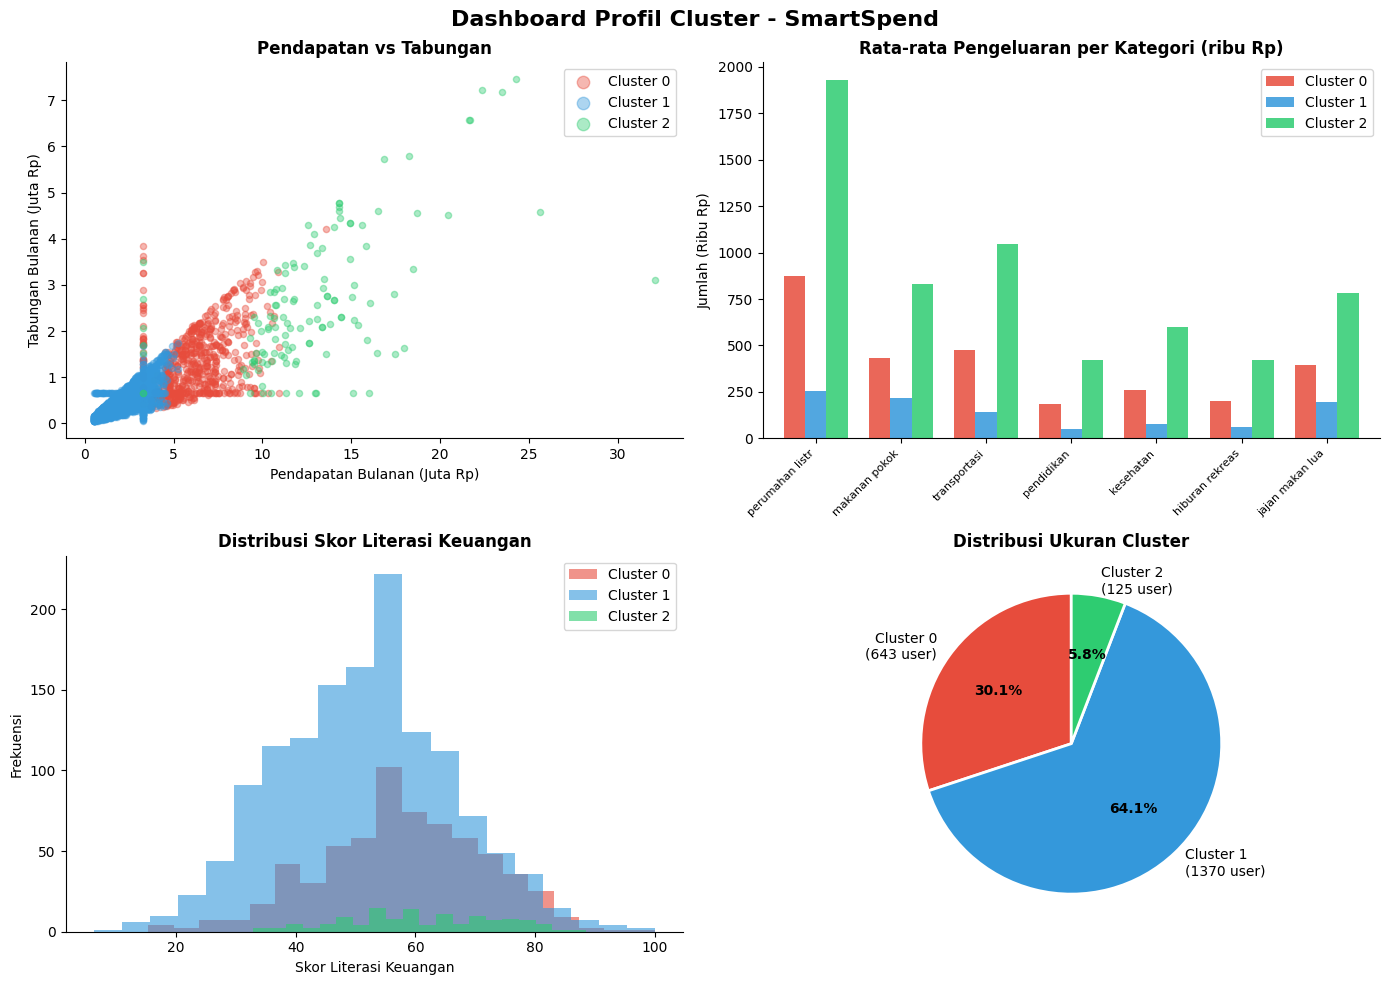

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Dashboard Profil Cluster - SmartSpend', fontsize=16, fontweight='bold')

colors_cl = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c'][:k_optimal]

# Plot 1: Pendapatan vs Tabungan per cluster
for cl in sorted(df['cluster'].unique()):
    subset = df[df['cluster'] == cl]
    axes[0, 0].scatter(
        subset['pendapatan_bulanan'] / 1e6,
        subset['tabungan_bulanan'] / 1e6,
        c=colors_cl[cl], label=f'Cluster {cl}', alpha=0.4, s=20
    )
axes[0, 0].set_title('Pendapatan vs Tabungan', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Pendapatan Bulanan (Juta Rp)')
axes[0, 0].set_ylabel('Tabungan Bulanan (Juta Rp)')
axes[0, 0].legend(markerscale=2)
axes[0, 0].spines['top'].set_visible(False)
axes[0, 0].spines['right'].set_visible(False)

# Plot 2: Rata-rata pengeluaran per kategori per cluster
pengeluaran_cols = [c for c in fitur_clustering if 'pengeluaran' in c and c != 'total_pengeluaran']
profil_pengeluaran = df.groupby('cluster')[pengeluaran_cols].mean() / 1e3  # dalam ribuan

profil_pengeluaran.T.plot(kind='bar', ax=axes[0, 1], color=colors_cl, alpha=0.85, width=0.75)
axes[0, 1].set_title('Rata-rata Pengeluaran per Kategori (ribu Rp)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Jumlah (Ribu Rp)')
axes[0, 1].set_xticklabels(
    [c.replace('pengeluaran_', '').replace('_', ' ')[:15] for c in pengeluaran_cols],
    rotation=45, ha='right', fontsize=8
)
axes[0, 1].legend([f'Cluster {i}' for i in range(k_optimal)])
axes[0, 1].spines['top'].set_visible(False)
axes[0, 1].spines['right'].set_visible(False)

# Plot 3: Distribusi skor literasi per cluster
for cl in sorted(df['cluster'].unique()):
    axes[1, 0].hist(
        df[df['cluster'] == cl]['skor_literasi_keuangan'],
        bins=20, alpha=0.6, label=f'Cluster {cl}',
        color=colors_cl[cl], edgecolor='none'
    )
axes[1, 0].set_title('Distribusi Skor Literasi Keuangan', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Skor Literasi Keuangan')
axes[1, 0].set_ylabel('Frekuensi')
axes[1, 0].legend()
axes[1, 0].spines['top'].set_visible(False)
axes[1, 0].spines['right'].set_visible(False)

# Plot 4: Ukuran tiap cluster
cluster_sizes = df['cluster'].value_counts().sort_index()
wedges, texts, autotexts = axes[1, 1].pie(
    cluster_sizes.values,
    labels=[f'Cluster {i}\n({n} user)' for i, n in cluster_sizes.items()],
    colors=colors_cl,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts: at.set_fontweight('bold')
axes[1, 1].set_title('Distribusi Ukuran Cluster', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


# Kesimpulan Sistem Rekomendasi

Sistem rekomendasi budgeting berbasis clustering berhasil dibangun dengan tahapan:

1. **Data Preparation** — fitur keuangan inti dipilih, missing values diimputasi, label di-drop sebelum clustering
2. **Normalisasi** — StandardScaler untuk menyamakan skala antar fitur
3. **K-Means Clustering** — jumlah cluster optimal ditentukan dengan Elbow + Silhouette Score
4. **Profil Cluster** — tiap cluster dianalisis berdasarkan rata-rata rasio tabungan, pendapatan, dan literasi keuangan
5. **Sistem Rekomendasi** — user baru di-assign ke cluster terdekat, lalu mendapat rekomendasi personal berdasarkan profil cluster dan data keuangan individu

Sistem ini siap diintegrasikan ke platform SmartSpend untuk memberikan rekomendasi budgeting yang tepat sasaran kepada setiap pengguna.

## 10. Content-based Filtering — Profil Teks & TF-IDF

Mengadaptasi teknik Content-based Filtering dari domain film ke domain keuangan:
- **Film**: `deskripsi + genre` → TF-IDF → cosine similarity antar film
- **Budgeting**: `kondisi keuangan (binning) + demografi` → TF-IDF → cosine similarity antar **profil user**

Hasil: menemukan user dengan kondisi keuangan paling mirip, lalu mengekstrak insight dari mereka sebagai konteks tambahan rekomendasi.


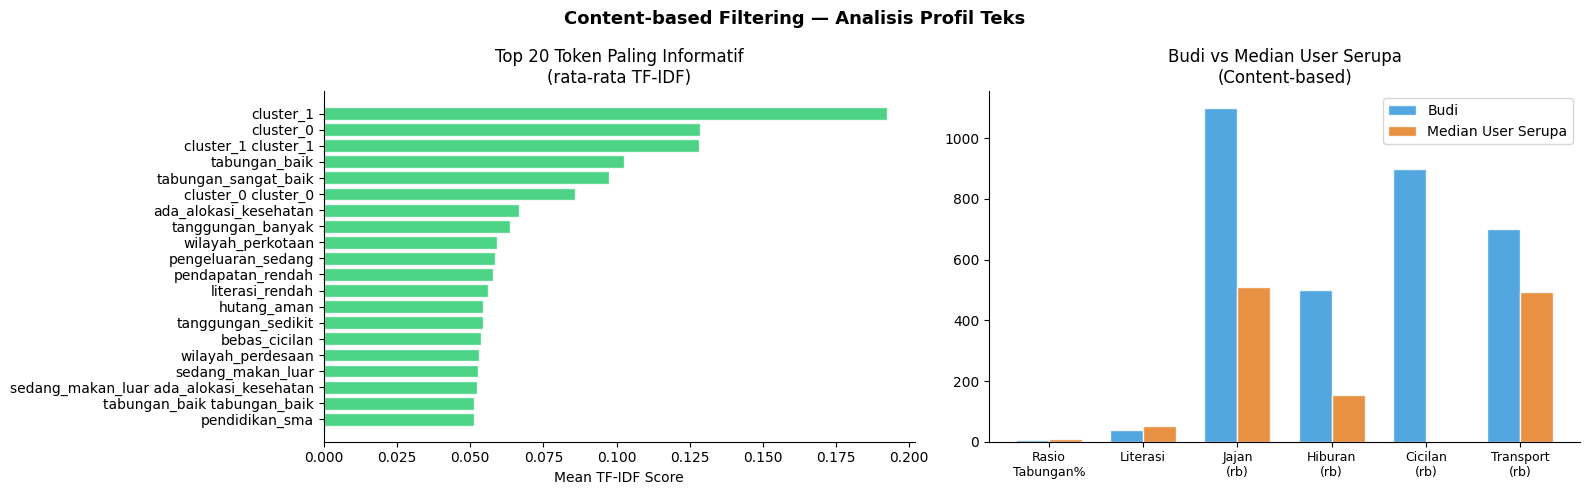

In [30]:
# Top token TF-IDF
import numpy as np
feature_names = tfidf.get_feature_names_out()
mean_tfidf    = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
top_idx       = mean_tfidf.argsort()[::-1][:20]
top_terms     = [feature_names[i] for i in top_idx]
top_scores    = [mean_tfidf[i] for i in top_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Content-based Filtering — Analisis Profil Teks', fontsize=13, fontweight='bold')

# Subplot 1: top tokens
axes[0].barh(top_terms[::-1], top_scores[::-1], color='#2ecc71', alpha=0.85, edgecolor='white')
axes[0].set_title('Top 20 Token Paling Informatif\n(rata-rata TF-IDF)')
axes[0].set_xlabel('Mean TF-IDF Score')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Subplot 2: perbandingan user Budi vs user serupa
data_budi  = list(users.values())[0]
hasil_budi = sistem_rekomendasi_user_baru(data_budi)
serupa_budi = hasil_budi['user_serupa']

# Definisi fitur & label bar chart
fitur_bar = [
    'rasio_tabungan_persen',
    'skor_literasi_keuangan',
    'pengeluaran_jajan_makan_luar',
    'pengeluaran_hiburan_rekreasi',
    'cicilan_hutang',
    'pengeluaran_transportasi',
]
label_bar = ['Rasio\nTabungan%', 'Literasi', 'Jajan\n(rb)', 'Hiburan\n(rb)', 'Cicilan\n(rb)', 'Transport\n(rb)']
skala_rb  = {'pengeluaran_jajan_makan_luar', 'pengeluaran_hiburan_rekreasi',
             'cicilan_hutang', 'pengeluaran_transportasi'}

# Nilai user Budi (dari dict input, bukan dari df)
user_vals = [
    data_budi.get(f, 0) / 1000 if f in skala_rb else data_budi.get(f, 0)
    for f in fitur_bar
]

# Nilai median user serupa (ambil dari kolom yg tersedia, fallback 0)
serupa_vals = [
    serupa_budi[f].median() / 1000 if f in skala_rb and f in serupa_budi.columns
    else serupa_budi[f].median() if f in serupa_budi.columns
    else 0
    for f in fitur_bar
]

x = np.arange(len(label_bar))
w = 0.35
axes[1].bar(x - w/2, user_vals,   w, label='Budi',               color='#3498db', alpha=0.85, edgecolor='white')
axes[1].bar(x + w/2, serupa_vals, w, label='Median User Serupa', color='#e67e22', alpha=0.85, edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(label_bar, fontsize=9)
axes[1].set_title('Budi vs Median User Serupa\n(Content-based)')
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


In [31]:
import pickle
import joblib

# Simpan model KMeans
joblib.dump(kmeans, 'kmeans_model.pkl')

# Simpan scaler
joblib.dump(scaler, 'scaler.pkl')

print("Model berhasil disimpan!")

Model berhasil disimpan!
